# Загрузка данных

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Данные взяты с сайта kaggle
[данные о продажах маркетплейса Amazon](https://www.kaggle.com/datasets/ammaraahmad/us-ecommerce-record-2020)

In [3]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/Z Аналитик данных ISA/Python/PN_14/amazon_market_data.csv')

In [4]:
df

,Order Date,Row ID,Order ID,Ship Mode,Customer ID,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,01-01-20,849,CA-2017-107503,Standard Class,GA-14725,Consumer,United States,Lorain,Ohio,44052,East,FUR-FU-10003878,Furniture,Furnishings,"Linden 10"" Round Wall Clock, Black",48.896,4,0.2,8.5568
1,01-01-20,4010,CA-2017-144463,Standard Class,SC-20725,Consumer,United States,Los Angeles,California,90036,West,FUR-FU-10001215,Furniture,Furnishings,"Howard Miller 11-1/2"" Diameter Brentwood Wall ...",474.430,11,0.0,199.2606
2,01-01-20,6683,CA-2017-154466,First Class,DP-13390,Home Office,United States,Franklin,Wisconsin,53132,Central,OFF-BI-10002012,Office Supplies,Binders,Wilson Jones Easy Flow II Sheet Lifters,3.600,2,0.0,1.7280
3,01-01-20,8070,CA-2017-151750,Standard Class,JM-15250,Consumer,United States,Huntsville,Texas,77340,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,454.560,5,0.2,-107.9580
4,01-01-20,8071,CA-2017-151750,Standard Class,JM-15250,Consumer,United States,Huntsville,Texas,77340,Central,FUR-FU-10002116,Furniture,Furnishings,"Tenex Carpeted, Granite-Look or Clear Contempo...",141.420,5,0.6,-187.3815
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3307,30-12-20,908,CA-2017-143259,Standard Class,PO-18865,Consumer,United States,New York City,New York,10009,East,TEC-PH-10004774,Technology,Phones,Gear Head AU3700S Headset,90.930,7,0.0,2.7279
3308,30-12-20,909,CA-2017-143259,Standard Class,PO-18865,Consumer,United States,New York City,New York,10009,East,OFF-BI-10003684,Office Supplies,Binders,Wilson Jones Legal Size Ring Binders,52.776,3,0.2,19.7910
3309,30-12-20,1297,CA-2017-115427,Standard Class,EB-13975,Corporate,United States,Fairfield,California,94533,West,OFF-BI-10002103,Office Supplies,Binders,"Cardinal Slant-D Ring Binder, Heavy Gauge Vinyl",13.904,2,0.2,4.5188
3310,30-12-20,1298,CA-2017-115427,Standard Class,EB-13975,Corporate,United States,Fairfield,California,94533,West,OFF-BI-10004632,Office Supplies,Binders,GBC Binding covers,20.720,2,0.2,6.4750


In [5]:
# Выводим информацию по датафрейму
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3312 entries, 0 to 3311
Data columns (total 19 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Order Date    3312 non-null   object 
 1   Row ID        3312 non-null   int64  
 2   Order ID      3312 non-null   object 
 3   Ship Mode     3312 non-null   object 
 4   Customer ID   3312 non-null   object 
 5   Segment       3312 non-null   object 
 6   Country       3312 non-null   object 
 7   City          3312 non-null   object 
 8   State         3312 non-null   object 
 9   Postal Code   3312 non-null   int64  
 10  Region        3312 non-null   object 
 11  Product ID    3312 non-null   object 
 12  Category      3312 non-null   object 
 13  Sub-Category  3312 non-null   object 
 14  Product Name  3312 non-null   object 
 15  Sales         3312 non-null   float64
 16  Quantity      3312 non-null   int64  
 17  Discount      3312 non-null   float64
 18  Profit        3312 non-null 

# Приведение столбцов к стилю camel_case

In [6]:
import re

# Функция для преобразования в camelCase
def to_camel_case(name):
    # Разделяем по пробелам и дефисам, приводим к нижнему регистру
    words = re.split(r'[\s\-]+', name.strip().lower())
    # Первое слово — с маленькой буквы, остальные — с заглавной
    return words[0] + ''.join(word.capitalize() for word in words[1:])

# Применяем к названиям столбцов
df.columns = [to_camel_case(col) for col in df.columns]

# Проверяем результат
print(df.columns.tolist())

['orderDate', 'rowId', 'orderId', 'shipMode', 'customerId', 'segment', 'country', 'city', 'state', 'postalCode', 'region', 'productId', 'category', 'subCategory', 'productName', 'sales', 'quantity', 'discount', 'profit']


# Приведение типов данных

In [7]:
#привести дату к типу datetime

# Преобразуем в datetime (автоопределение формата + защита от ошибок)
df['orderDate'] = pd.to_datetime(df['orderDate'], errors='coerce')

# Проверяем результат
print("Тип данных столбца orderDate:", df['orderDate'].dtype)

Тип данных столбца orderDate: datetime64[ns]


/tmp/ipython-input-1323345246.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['orderDate'] = pd.to_datetime(df['orderDate'], errors='coerce')


In [8]:
date_min = df['orderDate'].min()
date_max = df['orderDate'].max()
date_range = date_max - date_min
unique_days = df['orderDate'].nunique()

print("="*60)
print("ДИАПАЗОН ДАТ В ДАТАФРЕЙМЕ")
print("="*60)
print(f"Первая дата:    {date_min.strftime('%d %B %Y')} ({date_min.strftime('%A')})")
print(f"Последняя дата: {date_max.strftime('%d %B %Y')} ({date_max.strftime('%A')})")
print(f"Диапазон:       {date_range.days} дней ({date_range.days // 365} лет)")
print(f"Уникальных дней: {unique_days}")
print("="*60)

ДИАПАЗОН ДАТ В ДАТАФРЕЙМЕ
Первая дата:    01 January 2020 (Wednesday)
Последняя дата: 30 December 2020 (Wednesday)
Диапазон:       364 дней (0 лет)
Уникальных дней: 322


In [9]:
df

,orderDate,rowId,orderId,shipMode,customerId,segment,country,city,state,postalCode,region,productId,category,subCategory,productName,sales,quantity,discount,profit
0,2020-01-01,849,CA-2017-107503,Standard Class,GA-14725,Consumer,United States,Lorain,Ohio,44052,East,FUR-FU-10003878,Furniture,Furnishings,"Linden 10"" Round Wall Clock, Black",48.896,4,0.2,8.5568
1,2020-01-01,4010,CA-2017-144463,Standard Class,SC-20725,Consumer,United States,Los Angeles,California,90036,West,FUR-FU-10001215,Furniture,Furnishings,"Howard Miller 11-1/2"" Diameter Brentwood Wall ...",474.430,11,0.0,199.2606
2,2020-01-01,6683,CA-2017-154466,First Class,DP-13390,Home Office,United States,Franklin,Wisconsin,53132,Central,OFF-BI-10002012,Office Supplies,Binders,Wilson Jones Easy Flow II Sheet Lifters,3.600,2,0.0,1.7280
3,2020-01-01,8070,CA-2017-151750,Standard Class,JM-15250,Consumer,United States,Huntsville,Texas,77340,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,454.560,5,0.2,-107.9580
4,2020-01-01,8071,CA-2017-151750,Standard Class,JM-15250,Consumer,United States,Huntsville,Texas,77340,Central,FUR-FU-10002116,Furniture,Furnishings,"Tenex Carpeted, Granite-Look or Clear Contempo...",141.420,5,0.6,-187.3815
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3307,2020-12-30,908,CA-2017-143259,Standard Class,PO-18865,Consumer,United States,New York City,New York,10009,East,TEC-PH-10004774,Technology,Phones,Gear Head AU3700S Headset,90.930,7,0.0,2.7279
3308,2020-12-30,909,CA-2017-143259,Standard Class,PO-18865,Consumer,United States,New York City,New York,10009,East,OFF-BI-10003684,Office Supplies,Binders,Wilson Jones Legal Size Ring Binders,52.776,3,0.2,19.7910
3309,2020-12-30,1297,CA-2017-115427,Standard Class,EB-13975,Corporate,United States,Fairfield,California,94533,West,OFF-BI-10002103,Office Supplies,Binders,"Cardinal Slant-D Ring Binder, Heavy Gauge Vinyl",13.904,2,0.2,4.5188
3310,2020-12-30,1298,CA-2017-115427,Standard Class,EB-13975,Corporate,United States,Fairfield,California,94533,West,OFF-BI-10004632,Office Supplies,Binders,GBC Binding covers,20.720,2,0.2,6.4750


# Поиск дублей и пропусков в данных

In [10]:
df_duplicates = df.duplicated().sum()
print(df_duplicates)

0


Дублей в данных не обнаружено

In [11]:
missing = df.isnull().sum()
print(missing)

orderDate      0
rowId          0
orderId        0
shipMode       0
customerId     0
segment        0
country        0
city           0
state          0
postalCode     0
region         0
productId      0
category       0
subCategory    0
productName    0
sales          0
quantity       0
discount       0
profit         0
dtype: int64


Пропусков в данных нет

# Исследовательский анализ данных

In [12]:
df

,orderDate,rowId,orderId,shipMode,customerId,segment,country,city,state,postalCode,region,productId,category,subCategory,productName,sales,quantity,discount,profit
0,2020-01-01,849,CA-2017-107503,Standard Class,GA-14725,Consumer,United States,Lorain,Ohio,44052,East,FUR-FU-10003878,Furniture,Furnishings,"Linden 10"" Round Wall Clock, Black",48.896,4,0.2,8.5568
1,2020-01-01,4010,CA-2017-144463,Standard Class,SC-20725,Consumer,United States,Los Angeles,California,90036,West,FUR-FU-10001215,Furniture,Furnishings,"Howard Miller 11-1/2"" Diameter Brentwood Wall ...",474.430,11,0.0,199.2606
2,2020-01-01,6683,CA-2017-154466,First Class,DP-13390,Home Office,United States,Franklin,Wisconsin,53132,Central,OFF-BI-10002012,Office Supplies,Binders,Wilson Jones Easy Flow II Sheet Lifters,3.600,2,0.0,1.7280
3,2020-01-01,8070,CA-2017-151750,Standard Class,JM-15250,Consumer,United States,Huntsville,Texas,77340,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,454.560,5,0.2,-107.9580
4,2020-01-01,8071,CA-2017-151750,Standard Class,JM-15250,Consumer,United States,Huntsville,Texas,77340,Central,FUR-FU-10002116,Furniture,Furnishings,"Tenex Carpeted, Granite-Look or Clear Contempo...",141.420,5,0.6,-187.3815
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3307,2020-12-30,908,CA-2017-143259,Standard Class,PO-18865,Consumer,United States,New York City,New York,10009,East,TEC-PH-10004774,Technology,Phones,Gear Head AU3700S Headset,90.930,7,0.0,2.7279
3308,2020-12-30,909,CA-2017-143259,Standard Class,PO-18865,Consumer,United States,New York City,New York,10009,East,OFF-BI-10003684,Office Supplies,Binders,Wilson Jones Legal Size Ring Binders,52.776,3,0.2,19.7910
3309,2020-12-30,1297,CA-2017-115427,Standard Class,EB-13975,Corporate,United States,Fairfield,California,94533,West,OFF-BI-10002103,Office Supplies,Binders,"Cardinal Slant-D Ring Binder, Heavy Gauge Vinyl",13.904,2,0.2,4.5188
3310,2020-12-30,1298,CA-2017-115427,Standard Class,EB-13975,Corporate,United States,Fairfield,California,94533,West,OFF-BI-10004632,Office Supplies,Binders,GBC Binding covers,20.720,2,0.2,6.4750


In [13]:
# Считаем количество уникальных заказов
unique_orders = df['orderId'].nunique()

# Сколько всего строк в датафрейме (товарных позиций)
total_rows = len(df)

# Среднее количество товаров в одном заказе
avg_items_per_order = total_rows / unique_orders

print(f"Количество уникальных заказов: {unique_orders}")
print(f"Всего строк (товарных позиций): {total_rows}")
print(f"Среднее количество товаров в заказе: {avg_items_per_order:.2f}")

Количество уникальных заказов: 1687
Всего строк (товарных позиций): 3312
Среднее количество товаров в заказе: 1.96


В среднем клиенты заказывают по 1-2 товара за раз

In [14]:
# Считаем количество уникальных клиентов
unique_customers = df['customerId'].nunique()
unique_orders = df['orderId'].nunique()
orders_per_customer = unique_orders / unique_customers

print(f"Количество уникальных клиентов: {unique_customers}")
print(f"Уникальных заказов: {unique_orders}")
print(f"Среднее количество заказов на клиента: {orders_per_customer:.2f}")

Количество уникальных клиентов: 693
Уникальных заказов: 1687
Среднее количество заказов на клиента: 2.43


Многие клиенты возвращаются и делают повторные покупки

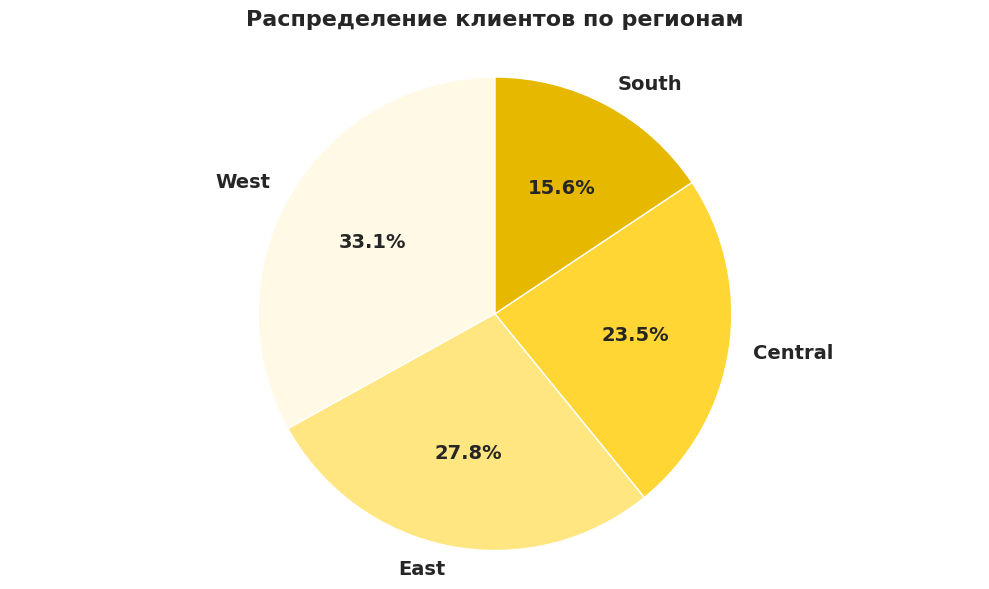

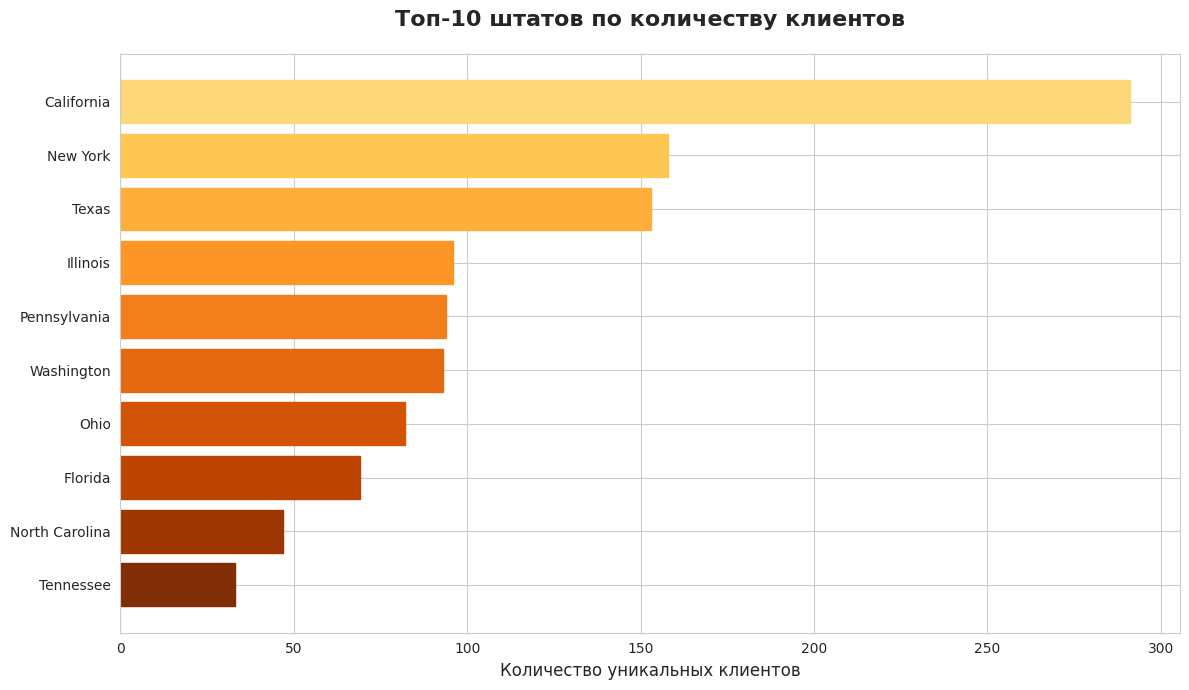

Статистика по локациям:
• Всего штатов: 47
• Всего городов: 350
• Топ-3 штата по клиентам:
state
California    291
New York      158
Texas         153


In [15]:
# изучить локацию пользователей (визуализировать)
import matplotlib.pyplot as plt
import seaborn as sns

# Настройка стиля
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Палитра в оттенках жёлтого: от светлого к насыщенному
yellow_palette = ['#FFF9E6', '#FFE680', '#FFD633', '#E6B800', '#997300']

# === 1. Распределение по регионам ===
region_counts = df['region'].value_counts()

plt.figure(figsize=(10, 6))
plt.pie(
    region_counts.values,
    labels=region_counts.index,
    autopct='%1.1f%%',
    colors=yellow_palette[:len(region_counts)],
    startangle=90,
    textprops={'fontsize': 14, 'weight': 'bold'}
)
plt.title('Распределение клиентов по регионам', fontsize=16, weight='bold', pad=20)
plt.axis('equal')
plt.tight_layout()
plt.show()

# === 2. Топ-10 штатов по количеству уникальных клиентов ===
top_states = df.groupby('state')['customerId'].nunique().nlargest(10)

plt.figure(figsize=(12, 7))
bars = plt.barh(
    top_states.index,
    top_states.values,
    color=yellow_palette[1]  # Основной жёлтый цвет
)

# Добавляем градиент: чем выше значение — тем темнее цвет
for i, bar in enumerate(bars):
    shade = 0.3 + (i / len(bars)) * 0.7  # градиент от светлого к тёмному
    bar.set_color(plt.cm.YlOrBr(shade))

plt.xlabel('Количество уникальных клиентов', fontsize=12)
plt.title('Топ-10 штатов по количеству клиентов', fontsize=16, weight='bold', pad=20)
plt.gca().invert_yaxis()  # Самый крупный штат сверху
plt.tight_layout()
plt.show()

# === Дополнительно: цифры для отчёта ===
print("Статистика по локациям:")
print(f"• Всего штатов: {df['state'].nunique()}")
print(f"• Всего городов: {df['city'].nunique()}")
print(f"• Топ-3 штата по клиентам:\n{top_states.head(3).to_string()}")

Основная доля клиентов сосредоточена в регионе West (33.1%), за ним следуют East (27.8%) и Central (23.5%), South имеет наименьшую долю (15.6%). В топ-10 штатов доминирует Калифорния с почти 300 уникальных клиентов, значительно превосходя другие штаты в рейтинге. Оба графика подчеркивают неравномерность географического распределения клиентской базы, где сформирован основной объем аудитории.

In [16]:
import plotly.express as px

# Маппинг полных названий штатов → двухбуквенные коды (для карты США)
state_to_code = {
    'Alabama': 'AL', 'Alaska': 'AK', 'Arizona': 'AZ', 'Arkansas': 'AR', 'California': 'CA',
    'Colorado': 'CO', 'Connecticut': 'CT', 'Delaware': 'DE', 'Florida': 'FL', 'Georgia': 'GA',
    'Hawaii': 'HI', 'Idaho': 'ID', 'Illinois': 'IL', 'Indiana': 'IN', 'Iowa': 'IA',
    'Kansas': 'KS', 'Kentucky': 'KY', 'Louisiana': 'LA', 'Maine': 'ME', 'Maryland': 'MD',
    'Massachusetts': 'MA', 'Michigan': 'MI', 'Minnesota': 'MN', 'Mississippi': 'MS', 'Missouri': 'MO',
    'Montana': 'MT', 'Nebraska': 'NE', 'Nevada': 'NV', 'New Hampshire': 'NH', 'New Jersey': 'NJ',
    'New Mexico': 'NM', 'New York': 'NY', 'North Carolina': 'NC', 'North Dakota': 'ND', 'Ohio': 'OH',
    'Oklahoma': 'OK', 'Oregon': 'OR', 'Pennsylvania': 'PA', 'Rhode Island': 'RI', 'South Carolina': 'SC',
    'South Dakota': 'SD', 'Tennessee': 'TN', 'Texas': 'TX', 'Utah': 'UT', 'Vermont': 'VT',
    'Virginia': 'VA', 'Washington': 'WA', 'West Virginia': 'WV', 'Wisconsin': 'WI', 'Wyoming': 'WY'
}

# Агрегация данных по штатам
state_stats = df.groupby('state').agg({
    'customerId': 'nunique',
    'sales': 'sum',
    'profit': 'sum'
}).reset_index()

# Добавляем двухбуквенный код штата
state_stats['state_code'] = state_stats['state'].map(state_to_code)

# Убираем строки без кода (на всякий случай)
state_stats = state_stats.dropna(subset=['state_code'])

# Создаём интерактивную карту
fig = px.choropleth(
    state_stats,
    locations='state_code',
    locationmode='USA-states',
    color='customerId',
    hover_name='state',
    hover_data={
        'state_code': False,
        'customerId': True,
        'sales': ':$.2f',
        'profit': ':$.2f'
    },
    scope='usa',
    color_continuous_scale=['#FFF9E6', '#FFE680', '#FFD633', '#E6B800', '#997300'],  # жёлтая палитра!
    labels={
        'customerId': 'Уникальные клиенты',
        'sales': 'Продажи',
        'profit': 'Прибыль'
    },
    title='Распределение клиентов по штатам США'
)

# Настройка внешнего вида
fig.update_layout(
    title={
        'text': 'Распределение клиентов по штатам США',
        'y': 0.95,
        'x': 0.5,
        'xanchor': 'center',
        'font': {'size': 24, 'color': '#E6B800', 'family': 'Arial'}
    },
    coloraxis_colorbar=dict(
        title='Клиенты',
        thickness=20,
        len=0.8,
        bgcolor='rgba(255,255,255,0.7)'
    ),
    geo=dict(bgcolor='rgba(0,0,0,0)'),
    plot_bgcolor='white',
    paper_bgcolor='white'
)

# Показываем карту
fig.show()


Карта распределения клиентов по штатам США показывает  географическую концентрацию клиентов в Калифорнии (насыщенный тёмно-жёлтый/коричневый цвет, >250) и в Техасе, Нью-Йорке и Флориде — эти штаты выделяются яркими оттенками жёлтого. Большая часть центральных и северных штатов (например, Монтана, Северная Дакота, Вайоминг) имеет очень низкую плотность клиентов (светло-жёлтые или почти белые) и указывает на значительный разрыв в охвате между крупными мегаполисами и менее населёнными регионами.

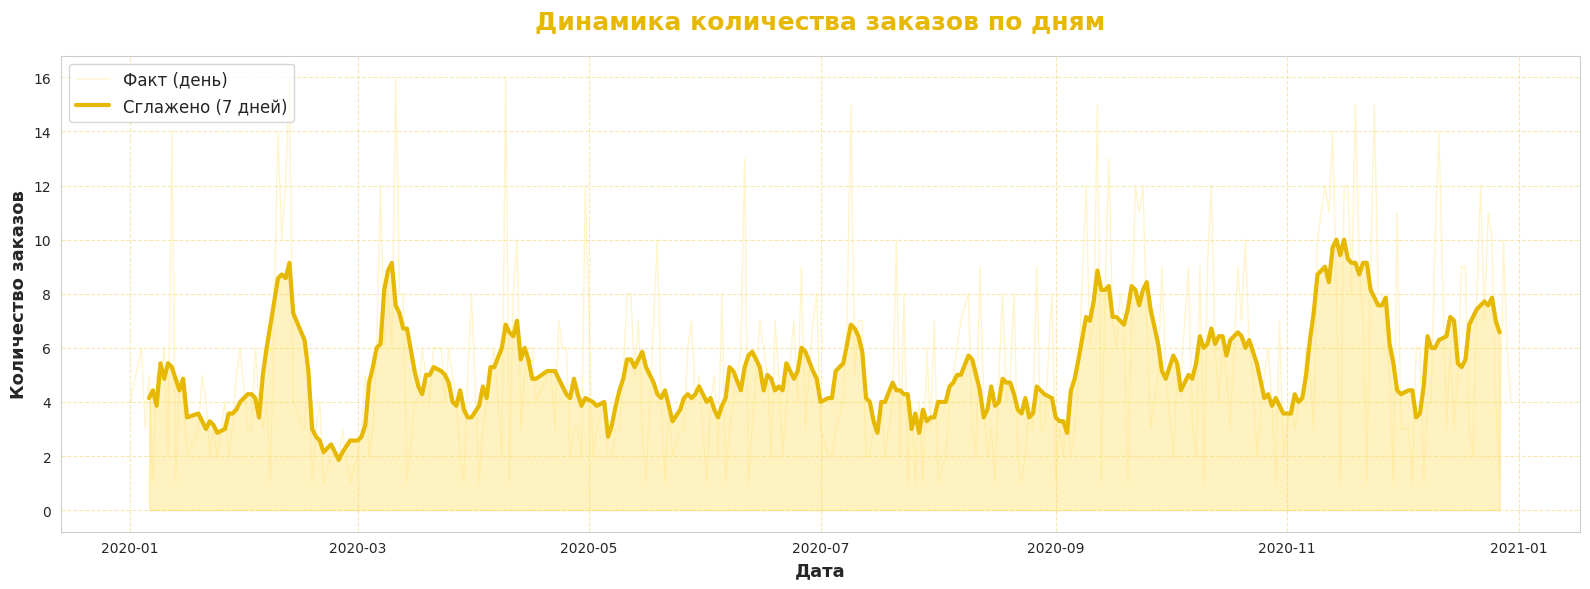

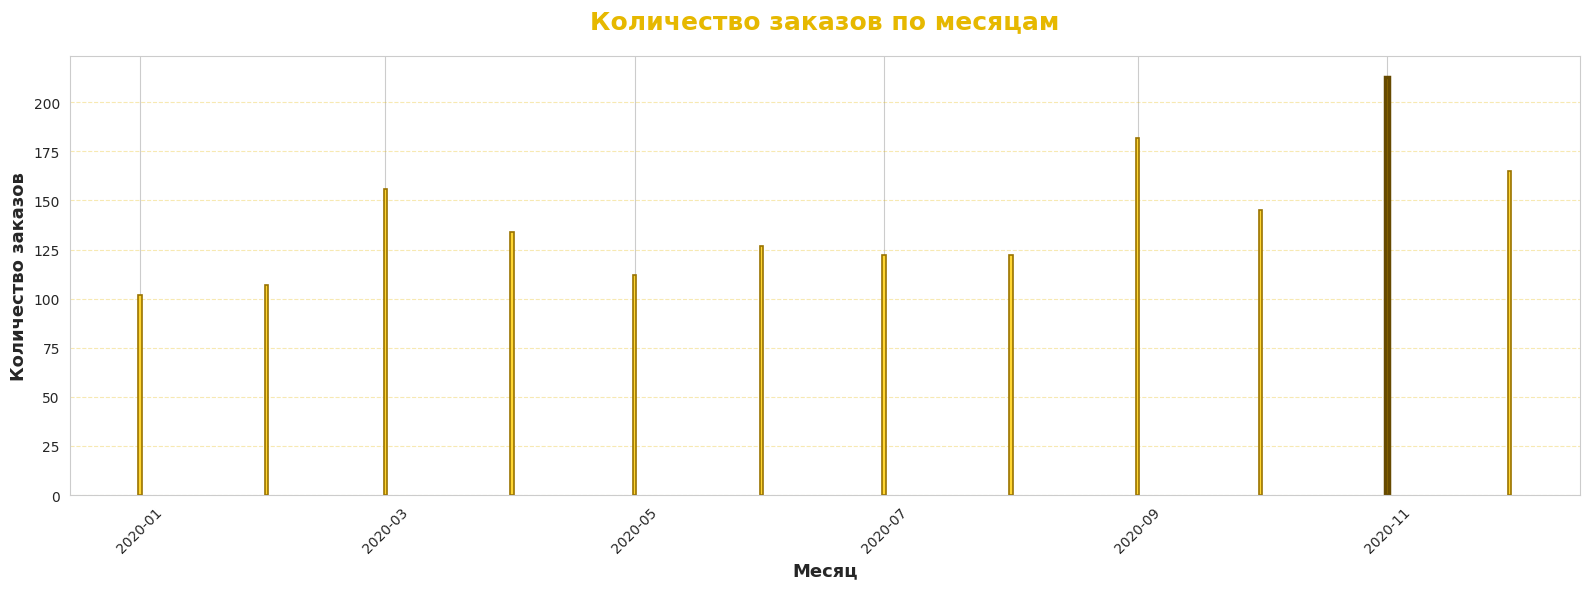

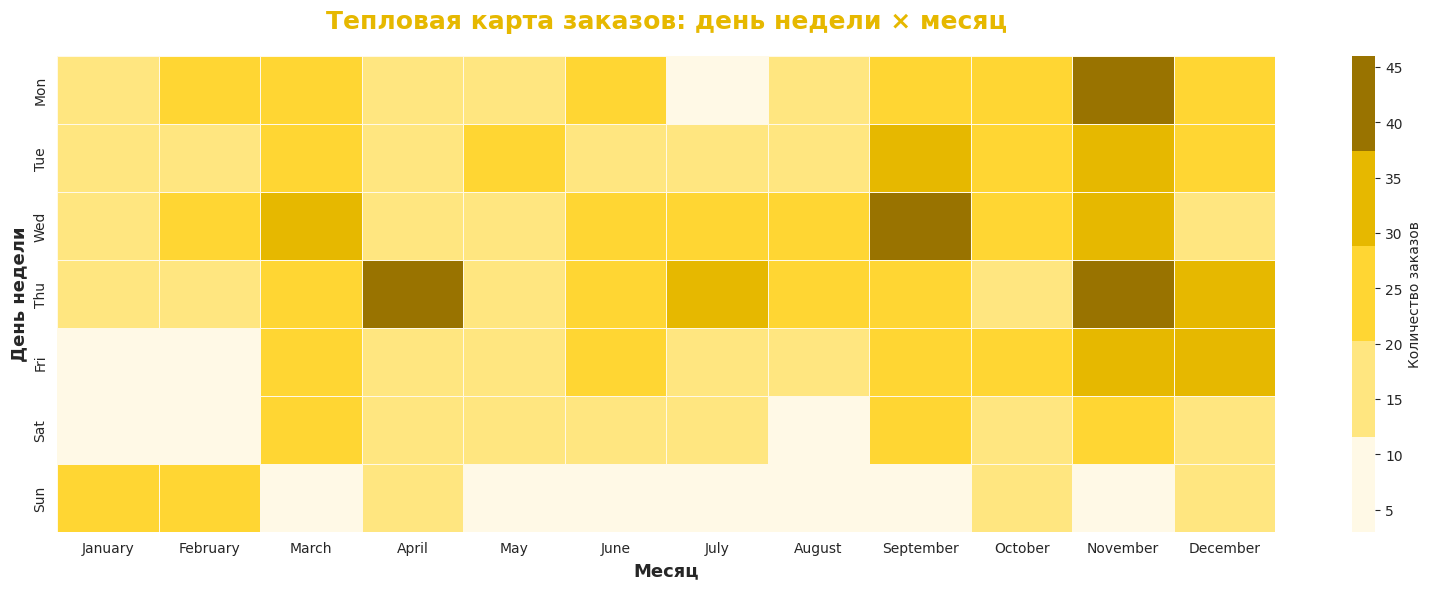


📈 Ключевые метрики динамики заказов:
• Всего дней с заказами: 322
• Максимум заказов за день: 16 (дата: 2020-02-12)
• Минимум заказов за день: 1 (дата: 2020-01-07)
• Самый активный месяц: November 2020
• Среднее заказов в день: 5.2


In [17]:
# изучить динамику кол-ва заказов по дате заказов

# Настройка стиля
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)
yellow_palette = ['#FFF9E6', '#FFE680', '#FFD633', '#E6B800', '#997300']

# === 1. Ежедневная динамика заказов ===
daily_orders = df.groupby('orderDate')['orderId'].nunique().reset_index()
daily_orders.columns = ['date', 'orderCount']

# Сглаживание: 7-дневное скользящее среднее
daily_orders['smoothed'] = daily_orders['orderCount'].rolling(window=7, center=True).mean()

plt.figure(figsize=(16, 6))
plt.plot(daily_orders['date'], daily_orders['orderCount'],
         color='#FFE680', alpha=0.4, linewidth=1, label='Факт (день)')
plt.plot(daily_orders['date'], daily_orders['smoothed'],
         color='#E6B800', linewidth=3, label='Сглажено (7 дней)')
plt.fill_between(daily_orders['date'], daily_orders['smoothed'],
                  color='#FFD633', alpha=0.3)

plt.title('Динамика количества заказов по дням', fontsize=18, weight='bold', color='#E6B800', pad=20)
plt.xlabel('Дата', fontsize=13, weight='bold')
plt.ylabel('Количество заказов', fontsize=13, weight='bold')
plt.legend(fontsize=12)
plt.grid(alpha=0.3, color='#E6B800', linestyle='--')
plt.tight_layout()
plt.show()

# === 2. Месячная агрегация ===
df['yearMonth'] = df['orderDate'].dt.to_period('M')
monthly_orders = df.groupby('yearMonth')['orderId'].nunique().reset_index()
monthly_orders.columns = ['month', 'orderCount']
monthly_orders['month'] = monthly_orders['month'].dt.to_timestamp()

plt.figure(figsize=(16, 6))
bars = plt.bar(monthly_orders['month'], monthly_orders['orderCount'],
               color=yellow_palette[2], edgecolor=yellow_palette[4], linewidth=1.2)

# Выделим пиковые месяцы
max_idx = monthly_orders['orderCount'].idxmax()
bars[max_idx].set_color('#997300')
bars[max_idx].set_edgecolor('#664a00')
bars[max_idx].set_linewidth(2.5)

plt.title('Количество заказов по месяцам', fontsize=18, weight='bold', color='#E6B800', pad=20)
plt.xlabel('Месяц', fontsize=13, weight='bold')
plt.ylabel('Количество заказов', fontsize=13, weight='bold')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3, color='#E6B800', linestyle='--')
plt.tight_layout()
plt.show()

# === 3. Тепловая карта: день недели × месяц ===
df['monthName'] = df['orderDate'].dt.month_name()
df['dayOfWeek'] = df['orderDate'].dt.dayofweek  # 0=Пн, 6=Вс
df['dayName'] = df['orderDate'].dt.day_name()

# Агрегация: уникальные заказы по дню недели и месяцу
heatmap_data = df.groupby(['dayOfWeek', 'monthName'])['orderId'].nunique().reset_index()
heatmap_data.columns = ['dayOfWeek', 'monthName', 'orderCount']

# Сортируем месяцы по календарю
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']
heatmap_data['monthOrder'] = heatmap_data['monthName'].apply(lambda x: month_order.index(x))
heatmap_data = heatmap_data.sort_values(['monthOrder', 'dayOfWeek'])

# Пивот для тепловой карты
pivot = heatmap_data.pivot(index='dayOfWeek', columns='monthName', values='orderCount')
pivot.index = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

plt.figure(figsize=(16, 6))
sns.heatmap(pivot[month_order],
            cmap=['#FFF9E6', '#FFE680', '#FFD633', '#E6B800', '#997300'],
            annot=False,
            linewidths=0.5,
            linecolor='#FFF9E6',
            cbar_kws={'label': 'Количество заказов'})

plt.title('Тепловая карта заказов: день недели × месяц',
          fontsize=18, weight='bold', color='#E6B800', pad=20)
plt.xlabel('Месяц', fontsize=13, weight='bold')
plt.ylabel('День недели', fontsize=13, weight='bold')
plt.tight_layout()
plt.show()

# === Статистика для отчёта ===
print("\n📈 Ключевые метрики динамики заказов:")
print(f"• Всего дней с заказами: {daily_orders.shape[0]}")
print(f"• Максимум заказов за день: {daily_orders['orderCount'].max()} "
      f"(дата: {daily_orders.loc[daily_orders['orderCount'].idxmax(), 'date'].date()})")
print(f"• Минимум заказов за день: {daily_orders['orderCount'].min()} "
      f"(дата: {daily_orders.loc[daily_orders['orderCount'].idxmin(), 'date'].date()})")
print(f"• Самый активный месяц: {monthly_orders.loc[monthly_orders['orderCount'].idxmax(), 'month'].strftime('%B %Y')}")
print(f"• Среднее заказов в день: {daily_orders['orderCount'].mean():.1f}")

График динамики заказов по дням показывает выраженную сезонность и цикличность: пиковые значения приходятся на конец года ноябрь–декабрь 2020 г., а также наблюдаются регулярные всплески каждые ~7 дней Столбчатая диаграмма по месяцам подтверждает эту тенденцию — ноябрь является самым активным месяцем (более 210 заказов), тогда как январь и февраль демонстрируют минимальную активность. Тепловая карта дополнительно выявляет паттерн по дням недели: наибольшее количество заказов приходится на четверг и пятницу.

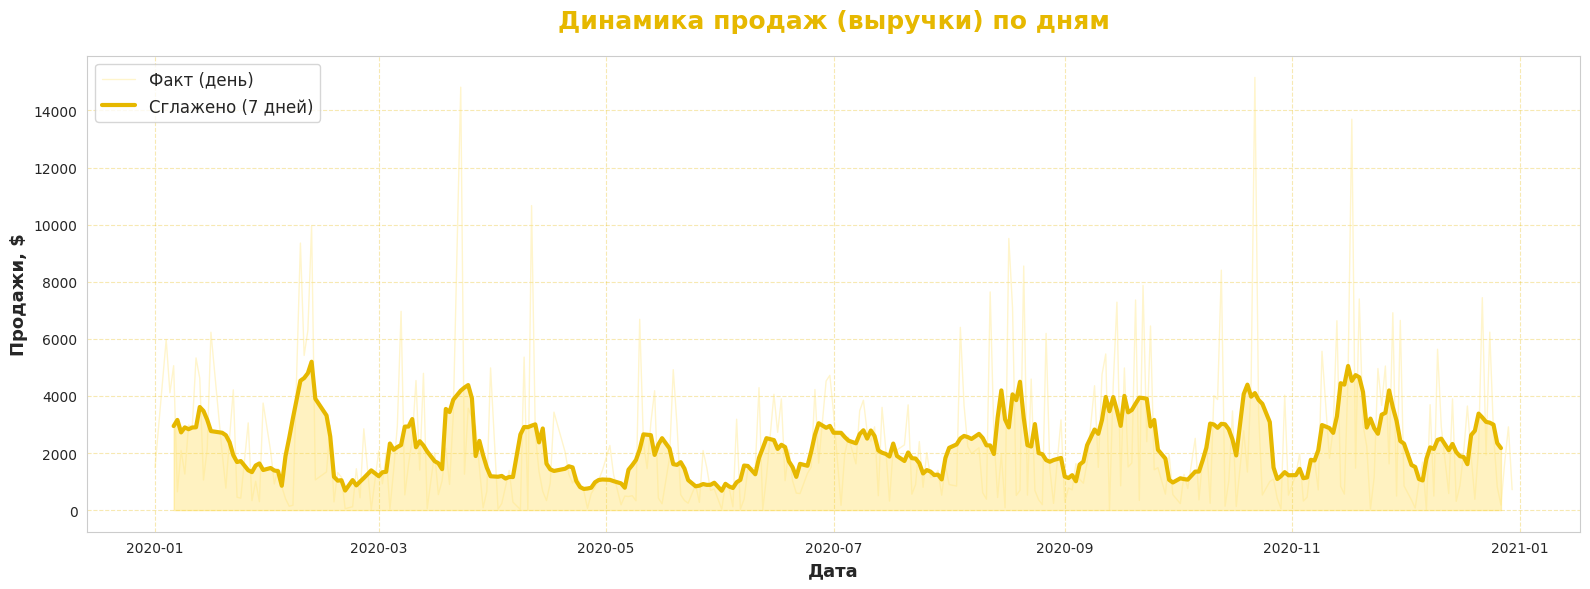

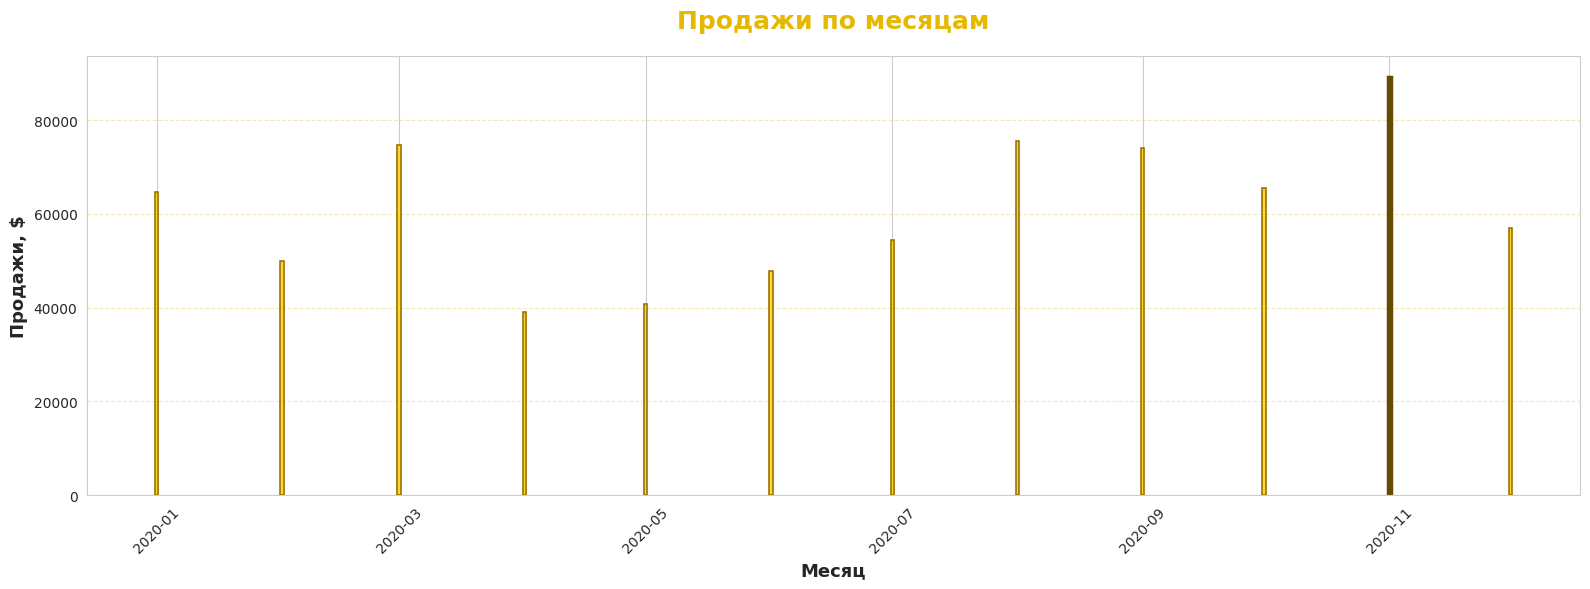

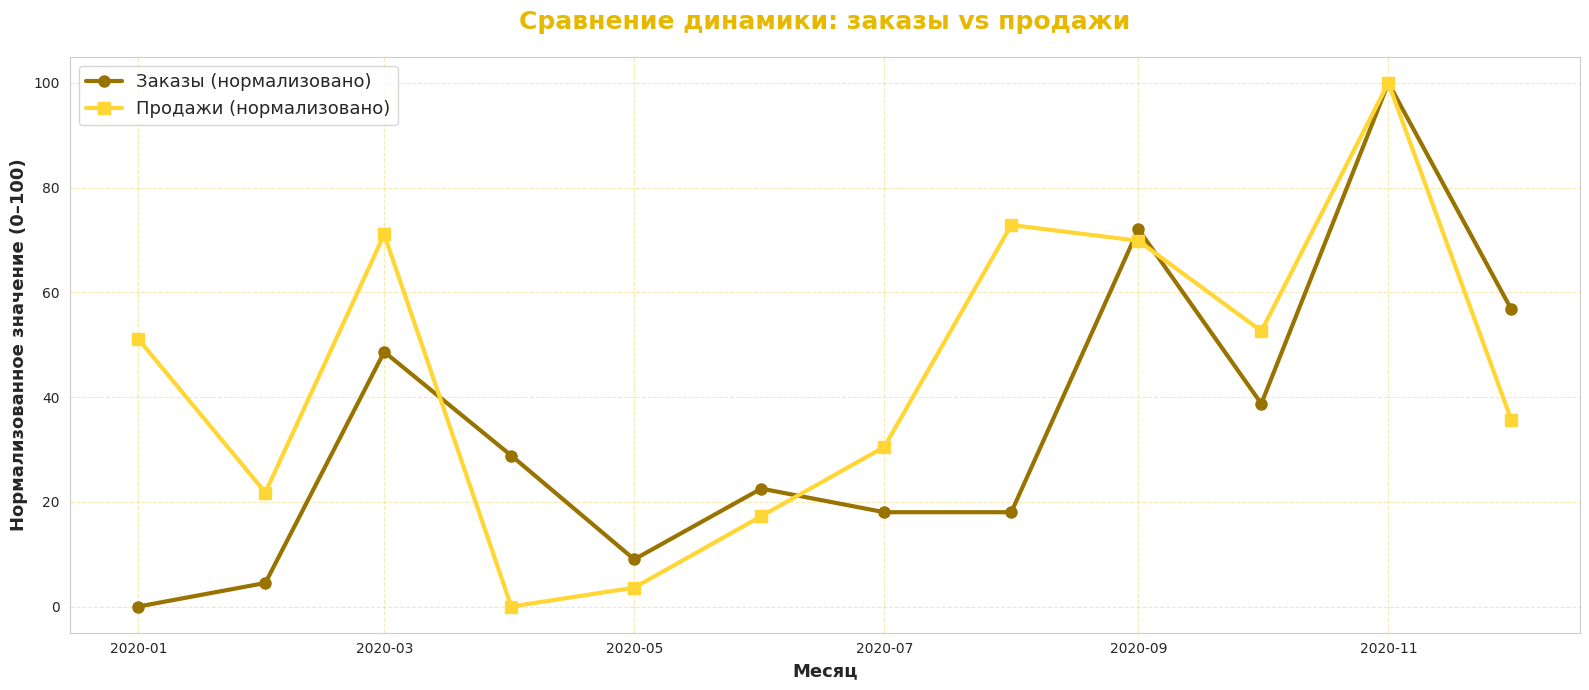


 Ключевые метрики продаж:
• Общая выручка: $733,215.26
• Средний чек (на заказ): $434.63
• Максимум продаж за день: $15,158.88 (дата: 2020-10-22)
• Самый прибыльный месяц: November 2020

 Корреляция заказов и продаж по месяцам: 0.652


In [18]:
# изучить динамику продаж по дате заказов

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)
yellow_palette = ['#FFF9E6', '#FFE680', '#FFD633', '#E6B800', '#997300']

# === 1. Ежедневная динамика продаж ===
daily_sales = df.groupby('orderDate')['sales'].sum().reset_index()
daily_sales.columns = ['date', 'salesAmount']

# Сглаживание: 7-дневное скользящее среднее
daily_sales['smoothed'] = daily_sales['salesAmount'].rolling(window=7, center=True).mean()

plt.figure(figsize=(16, 6))
plt.plot(daily_sales['date'], daily_sales['salesAmount'],
         color='#FFE680', alpha=0.4, linewidth=1, label='Факт (день)')
plt.plot(daily_sales['date'], daily_sales['smoothed'],
         color='#E6B800', linewidth=3, label='Сглажено (7 дней)')
plt.fill_between(daily_sales['date'], daily_sales['smoothed'],
                  color='#FFD633', alpha=0.3)

plt.title('Динамика продаж (выручки) по дням', fontsize=18, weight='bold', color='#E6B800', pad=20)
plt.xlabel('Дата', fontsize=13, weight='bold')
plt.ylabel('Продажи, $', fontsize=13, weight='bold')
plt.legend(fontsize=12)
plt.grid(alpha=0.3, color='#E6B800', linestyle='--')
plt.tight_layout()
plt.show()

# === 2. Месячная агрегация продаж ===
df['yearMonth'] = df['orderDate'].dt.to_period('M')
monthly_sales = df.groupby('yearMonth')['sales'].sum().reset_index()
monthly_sales.columns = ['month', 'salesAmount']
monthly_sales['month'] = monthly_sales['month'].dt.to_timestamp()

plt.figure(figsize=(16, 6))
bars = plt.bar(monthly_sales['month'], monthly_sales['salesAmount'],
               color=yellow_palette[2], edgecolor=yellow_palette[4], linewidth=1.2)

# Выделяем пик продаж
max_idx = monthly_sales['salesAmount'].idxmax()
bars[max_idx].set_color('#997300')
bars[max_idx].set_edgecolor('#664a00')
bars[max_idx].set_linewidth(2.5)

plt.title('Продажи по месяцам', fontsize=18, weight='bold', color='#E6B800', pad=20)
plt.xlabel('Месяц', fontsize=13, weight='bold')
plt.ylabel('Продажи, $', fontsize=13, weight='bold')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3, color='#E6B800', linestyle='--')
plt.tight_layout()
plt.show()

# === 3. Сравнение: заказы vs продажи (нормализованные) ===
# Группируем по месяцу обе метрики
monthly_compare = df.groupby('yearMonth').agg({
    'orderId': 'nunique',
    'sales': 'sum'
}).reset_index()

monthly_compare.columns = ['month', 'orderCount', 'salesAmount']
monthly_compare['month'] = monthly_compare['month'].dt.to_timestamp()

# Нормализуем для сравнения на одном графике (0–100)
monthly_compare['orders_norm'] = (monthly_compare['orderCount'] - monthly_compare['orderCount'].min()) / \
                                 (monthly_compare['orderCount'].max() - monthly_compare['orderCount'].min()) * 100
monthly_compare['sales_norm'] = (monthly_compare['salesAmount'] - monthly_compare['salesAmount'].min()) / \
                                (monthly_compare['salesAmount'].max() - monthly_compare['salesAmount'].min()) * 100

plt.figure(figsize=(16, 7))
plt.plot(monthly_compare['month'], monthly_compare['orders_norm'],
         marker='o', linewidth=3, markersize=8, color='#997300', label='Заказы (нормализовано)')
plt.plot(monthly_compare['month'], monthly_compare['sales_norm'],
         marker='s', linewidth=3, markersize=8, color='#FFD633', label='Продажи (нормализовано)')

plt.title('Сравнение динамики: заказы vs продажи', fontsize=18, weight='bold', color='#E6B800', pad=20)
plt.xlabel('Месяц', fontsize=13, weight='bold')
plt.ylabel('Нормализованное значение (0–100)', fontsize=13, weight='bold')
plt.legend(fontsize=13, loc='best')
plt.grid(alpha=0.3, color='#E6B800', linestyle='--')
plt.tight_layout()
plt.show()

# === Статистика ===
print("\n Ключевые метрики продаж:")
print(f"• Общая выручка: ${df['sales'].sum():,.2f}")
print(f"• Средний чек (на заказ): ${df.groupby('orderId')['sales'].sum().mean():.2f}")
print(f"• Максимум продаж за день: ${daily_sales['salesAmount'].max():,.2f} "
      f"(дата: {daily_sales.loc[daily_sales['salesAmount'].idxmax(), 'date'].date()})")
print(f"• Самый прибыльный месяц: {monthly_sales.loc[monthly_sales['salesAmount'].idxmax(), 'month'].strftime('%B %Y')}")
print(f"\n Корреляция заказов и продаж по месяцам: "
      f"{monthly_compare['orderCount'].corr(monthly_compare['salesAmount']):.3f}")

Динамика выручки по дням и месяцам демонстрирует устойчивую сезонную модель: пик продаж приходится на ноябрь 2020 г. (89 тыс. у.е.), что совпадает с рекордным днём (15 158.88 у.е.) и самым прибыльным месяцем, а средний чек в 434.63 у.е. указывает на относительно крупные заказы. Нормализованный график подтверждает положительную корреляцию (0.652) между количеством заказов и выручкой — обе метрики растут и падают синхронно, особенно в марте, сентябре и ноябре. Данные говорят о росте продаж обусловленнном  увеличением объёма заказов и сохранением среднего чека на стабильном уровне.

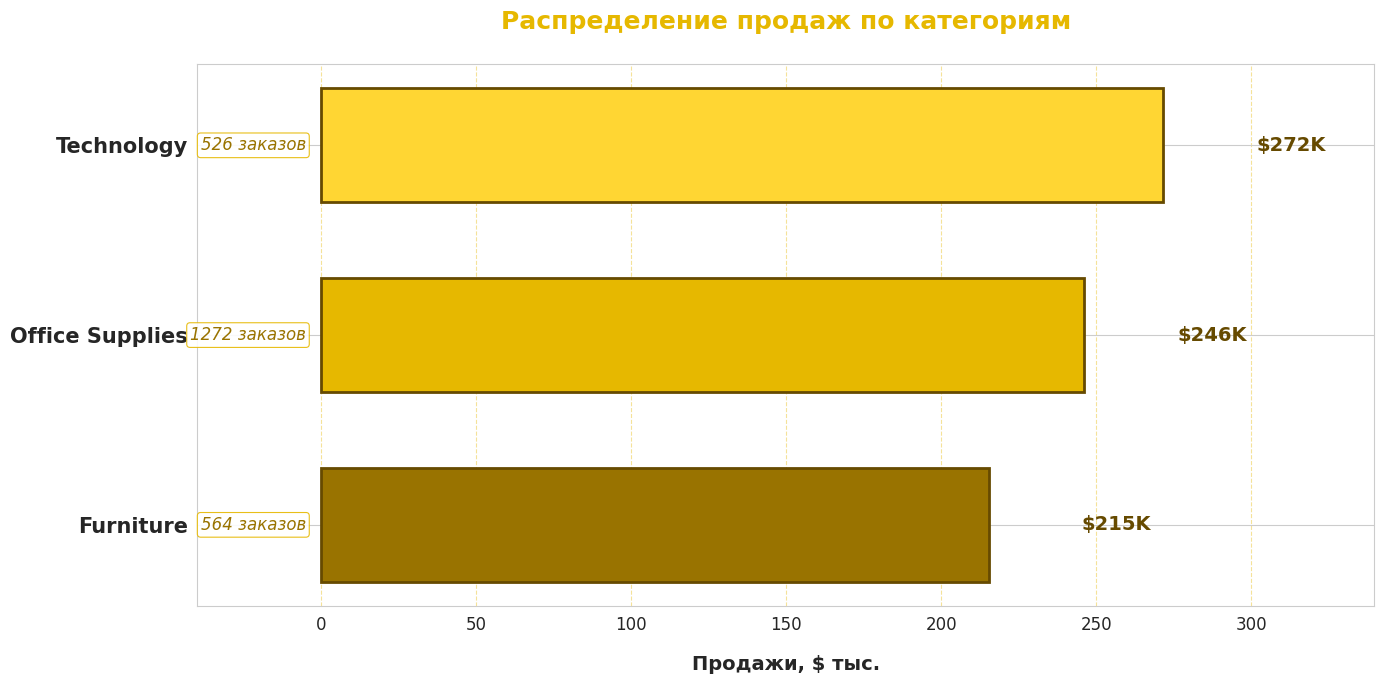

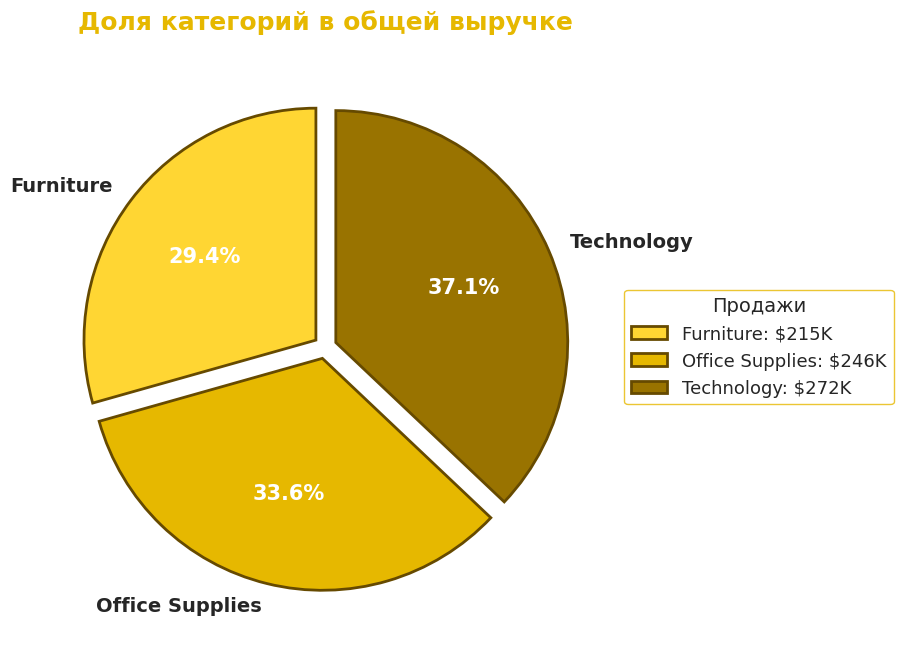


РАСПРЕДЕЛЕНИЕ ПРОДАЖ ПО КАТЕГОРИЯМ
Technology           | $    272K |  37.1% |  526 заказов
Office Supplies      | $    246K |  33.6% | 1272 заказов
Furniture            | $    215K |  29.4% |  564 заказов
------------------------------------------------------------
ИТОГО                | $    733K | 100.0% | 1687 заказов


In [19]:
# изучить распределение продаж по категориям заказов

import numpy as np

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12
yellow_palette = ['#FFF9E6', '#FFE680', '#FFD633', '#E6B800', '#997300']

# Агрегация данных
category_stats = df.groupby('category').agg({
    'sales': 'sum',
    'orderId': 'nunique'
}).reset_index()

category_stats.columns = ['category', 'totalSales', 'orderCount']
category_stats = category_stats.sort_values('totalSales', ascending=True).reset_index(drop=True)

# === 1. Горизонтальная столбчатая диаграмма (лучше читается) ===
# === Горизонтальная столбчатая диаграмма ===
# === Горизонтальная столбчатая диаграмма с НАДПИСЯМИ МЕЖДУ КАТЕГОРИЕЙ И СТОЛБЦОМ ===
fig, ax = plt.subplots(figsize=(14, 7))

y_pos = np.arange(len(category_stats))
bars = ax.barh(
    y_pos,
    category_stats['totalSales'] / 1000,
    color=[yellow_palette[4], yellow_palette[3], yellow_palette[2]],
    edgecolor='#664a00',
    linewidth=2,
    height=0.6
)

# Устанавливаем отступ от левого края (чтобы надписи не наезжали)
ax.set_xlim(left=-40, right=category_stats['totalSales'].max() / 1000 * 1.25)

for i, (bar, sales, orders) in enumerate(zip(bars, category_stats['totalSales'], category_stats['orderCount'])):
    width = bar.get_width()

    # Сумма продаж справа от столбца
    ax.text(width + 30, bar.get_y() + bar.get_height()/2,
            f'${sales/1000:.0f}K',
            va='center', ha='left', fontsize=14, weight='bold', color='#664a00')

    # 🔑 НАДПИСИ ЗАКАЗОВ МЕЖДУ КАТЕГОРИЕЙ И СТОЛБЦОМ
    ax.text(-5, bar.get_y() + bar.get_height()/2,  # ← ключевое: X = -5 (ближе к 0!)
            f'{orders} заказов',
            va='center', ha='right',  # выравнивание ВПРАВО
            fontsize=12,
            color='#997300',
            style='italic',
            bbox=dict(
                boxstyle='round,pad=0.2',  # меньше отступы
                facecolor='white',
                edgecolor='#E6B800',
                linewidth=0.8,  # тонкая рамка
                alpha=0.9  # полупрозрачность
            ))

# Названия категорий СЛЕВА от надписей заказов
ax.set_yticks(y_pos)
ax.set_yticklabels(category_stats['category'], fontsize=15, weight='bold', ha='right')

# Оси и сетка
ax.set_xlabel('Продажи, $ тыс.', fontsize=14, weight='bold', labelpad=15)
ax.set_title('Распределение продаж по категориям',
             fontsize=18, weight='bold', color='#E6B800', pad=25)
ax.grid(axis='x', alpha=0.4, color='#E6B800', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.show()
# === 2. Круговая диаграмма (чистая, без перегруза) ===
fig, ax = plt.subplots(figsize=(9, 9))

sales_values = category_stats['totalSales'].values
categories = category_stats['category'].values

wedges, texts, autotexts = ax.pie(
    sales_values,
    labels=categories,
    autopct=lambda pct: f'{pct:.1f}%',
    colors=[yellow_palette[2], yellow_palette[3], yellow_palette[4]],
    startangle=90,
    textprops={'fontsize': 14, 'weight': 'bold'},
    explode=[0.05, 0.05, 0.05],  # лёгкий вынос сегментов
    wedgeprops={'edgecolor': '#664a00', 'linewidth': 2}
)

# Форматирование процентов внутри сегментов
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_weight('bold')
    autotext.set_fontsize(15)

# Добавляем легенду с абсолютными значениями
legend_labels = [f'{cat}: ${val/1000:.0f}K' for cat, val in zip(categories, sales_values)]
ax.legend(legend_labels,
          loc='center left',
          bbox_to_anchor=(1, 0, 0.5, 1),
          fontsize=13,
          frameon=True,
          facecolor='white',
          edgecolor='#E6B800',
          title='Продажи',
          title_fontsize=14)

ax.set_title('Доля категорий в общей выручке',
             fontsize=18, weight='bold', color='#E6B800', pad=20)

plt.tight_layout()
plt.show()

# === Итоговая таблица ===
print("\n" + "="*60)
print("РАСПРЕДЕЛЕНИЕ ПРОДАЖ ПО КАТЕГОРИЯМ")
print("="*60)
total = category_stats['totalSales'].sum()
for _, row in category_stats.sort_values('totalSales', ascending=False).iterrows():
    pct = row['totalSales'] / total * 100
    print(f"{row['category']:20s} | ${row['totalSales']/1000:>7.0f}K | {pct:>5.1f}% | {row['orderCount']:>4d} заказов")
print("-"*60)
print(f"{'ИТОГО':20s} | ${total/1000:>7.0f}K | 100.0% | {df['orderId'].nunique():>4d} заказов")
print("="*60)

Категория Technology является лидером по выручке (272 тыс. у.е., 37.1% от общего объёма) с наименьшим количеством заказов (526), высоким средним чеком (~ 517 у.е.) и имеет стратегическую значимость  для дохода. Категория Office Supplies показывает вторую по величине выручку (246 тыс. у.е., 33.6%) за счёт большего числа заказов (1272) с низким средним чеком (~194), то есть сегмент с высокой частотой покупок. Категория Furniture занимает третье место по выручке (215 тыс. у.е., 29.4%) при умеренном количестве заказов (564), среднем чеке ~381 у.е. показывает балансе между объёмом и ценной заказа.

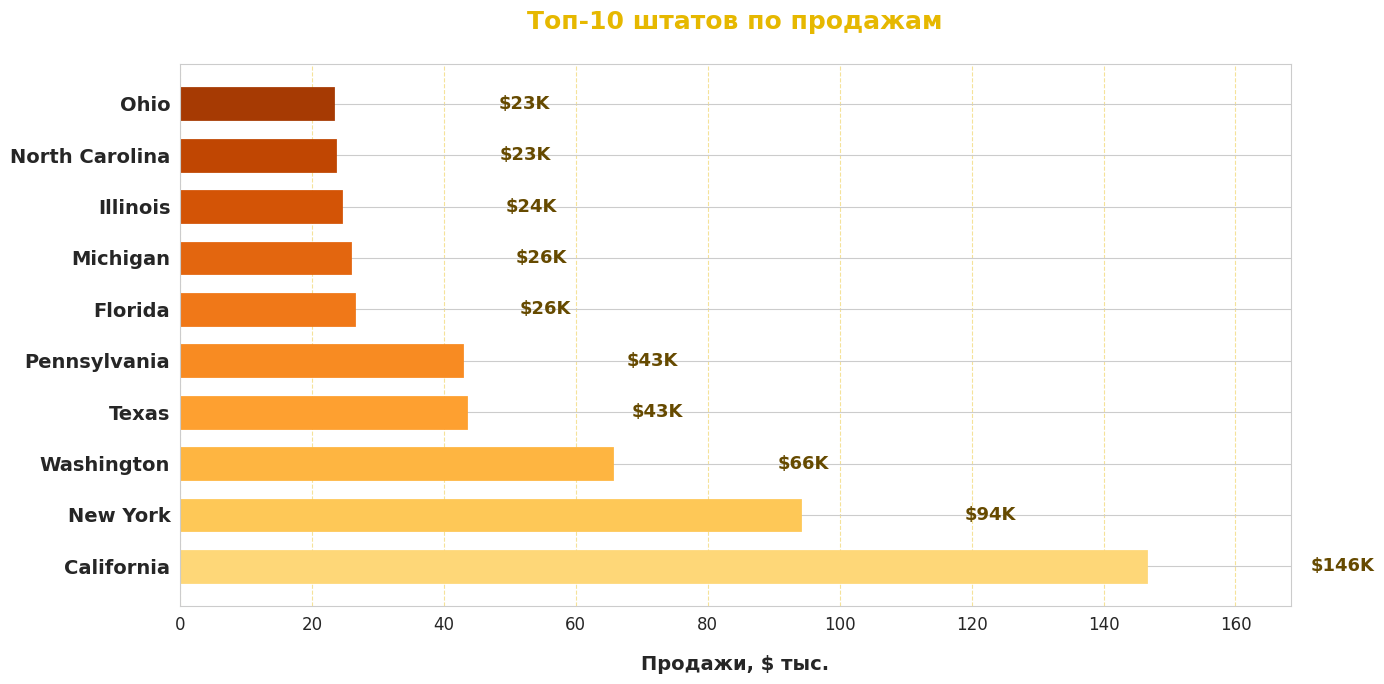

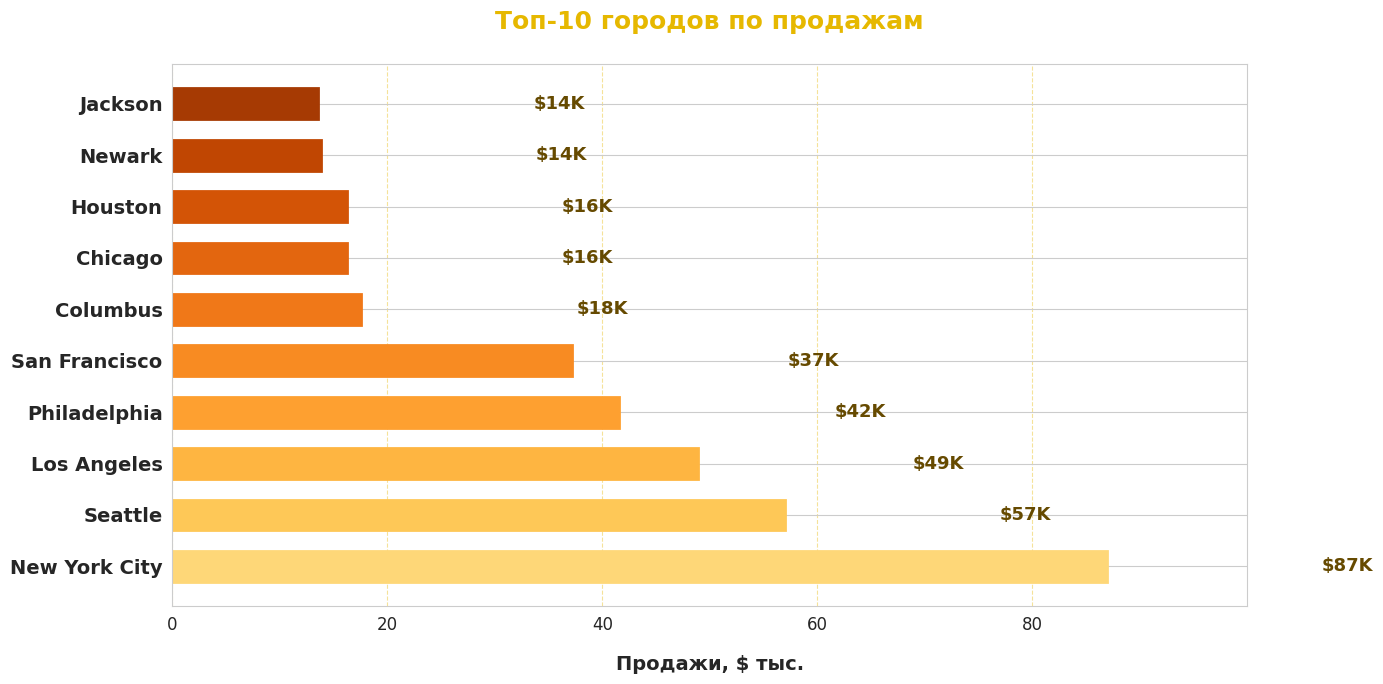

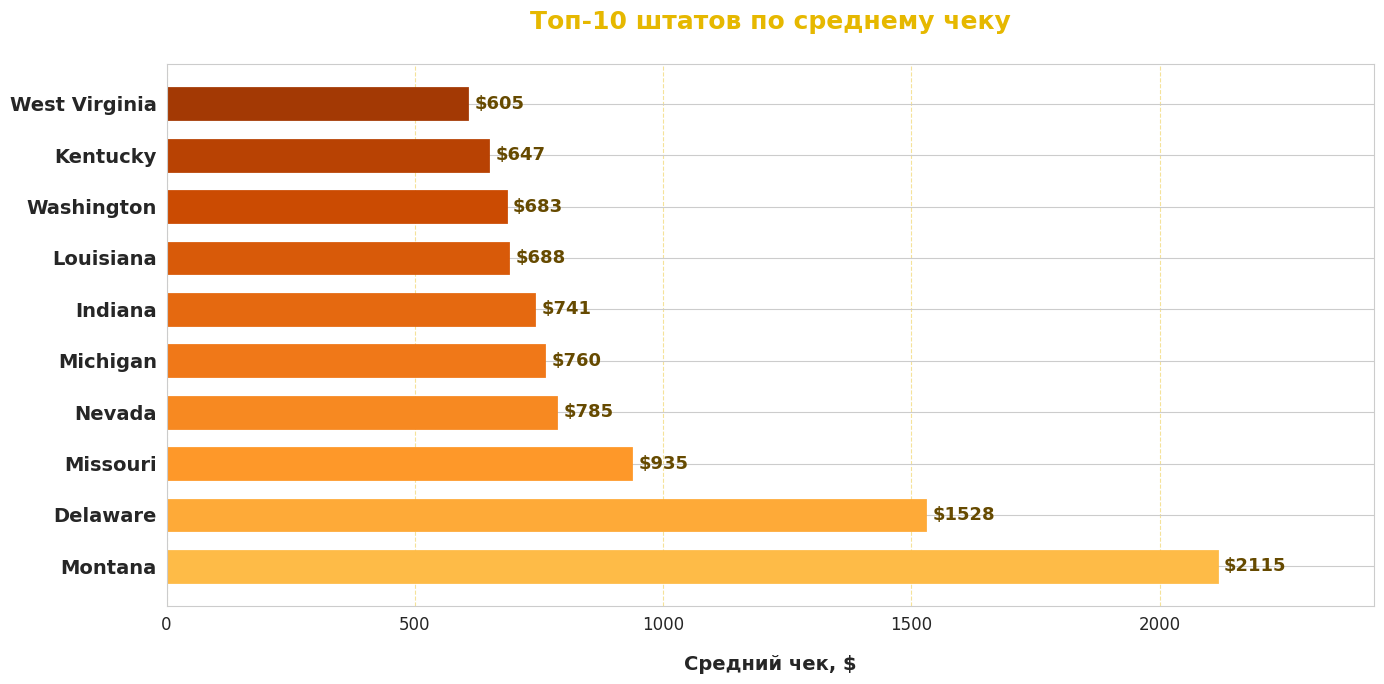


ТОП-5 ШТАТОВ ПО ПРОДАЖАМ
1. California           | $    146K
2. New York             | $     94K
3. Washington           | $     66K
4. Texas                | $     43K
5. Pennsylvania         | $     43K

ТОП-5 ГОРОДОВ ПО ПРОДАЖАМ
1. New York City        | $     87K
2. Seattle              | $     57K
3. Los Angeles          | $     49K
4. Philadelphia         | $     42K
5. San Francisco        | $     37K

ИНСАЙТЫ
• Всего штатов в датасете: 47
• Всего городов в датасете: 350
• Лидер по продажам: California ($146K)
• Самый прибыльный город: New York City ($87K)
• Средний чек в топовом штате: $2115


In [20]:
# изучить распределение продаж по городам (штатам)

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['font.size'] = 12
yellow_palette = ['#FFF9E6', '#FFE680', '#FFD633', '#E6B800', '#997300']

# === 1. Топ-10 штатов по продажам ===
top_states_sales = df.groupby('state')['sales'].sum().nlargest(10).reset_index()

fig, ax = plt.subplots(figsize=(14, 7))
y_pos = np.arange(len(top_states_sales))

bars = ax.barh(
    y_pos,
    top_states_sales['sales'] / 1000,
    color=yellow_palette[2],
    edgecolor=yellow_palette[4],
    linewidth=2,
    height=0.6
)

# Градиент: чем выше продажи — тем темнее цвет
for i, bar in enumerate(bars):
    shade = 0.3 + (i / len(bars)) * 0.6
    bar.set_color(plt.cm.YlOrBr(shade))

# Подписи значений справа от столбцов
for i, (bar, sales) in enumerate(zip(bars, top_states_sales['sales'])):
    width = bar.get_width()
    ax.text(width + 25, bar.get_y() + bar.get_height()/2,
            f'${sales/1000:.0f}K',
            va='center', ha='left', fontsize=13, weight='bold', color='#664a00')

# Названия штатов
ax.set_yticks(y_pos)
ax.set_yticklabels(top_states_sales['state'], fontsize=14, weight='bold')

ax.set_xlabel('Продажи, $ тыс.', fontsize=14, weight='bold', labelpad=15)
ax.set_title('Топ-10 штатов по продажам',
             fontsize=18, weight='bold', color='#E6B800', pad=25)
ax.grid(axis='x', alpha=0.4, color='#E6B800', linestyle='--', linewidth=0.8)
ax.set_xlim(right=top_states_sales['sales'].max() / 1000 * 1.15)
plt.tight_layout()
plt.show()

# === 2. Топ-10 городов по продажам ===
top_cities_sales = df.groupby('city')['sales'].sum().nlargest(10).reset_index()

fig, ax = plt.subplots(figsize=(14, 7))
y_pos = np.arange(len(top_cities_sales))

bars = ax.barh(
    y_pos,
    top_cities_sales['sales'] / 1000,
    color=yellow_palette[2],
    edgecolor=yellow_palette[4],
    linewidth=2,
    height=0.6
)

# Градиент
for i, bar in enumerate(bars):
    shade = 0.3 + (i / len(bars)) * 0.6
    bar.set_color(plt.cm.YlOrBr(shade))

# Подписи значений справа
for i, (bar, sales) in enumerate(zip(bars, top_cities_sales['sales'])):
    width = bar.get_width()
    ax.text(width + 20, bar.get_y() + bar.get_height()/2,
            f'${sales/1000:.0f}K',
            va='center', ha='left', fontsize=13, weight='bold', color='#664a00')

# Названия городов
ax.set_yticks(y_pos)
ax.set_yticklabels(top_cities_sales['city'], fontsize=14, weight='bold')

ax.set_xlabel('Продажи, $ тыс.', fontsize=14, weight='bold', labelpad=15)
ax.set_title('Топ-10 городов по продажам',
             fontsize=18, weight='bold', color='#E6B800', pad=25)
ax.grid(axis='x', alpha=0.4, color='#E6B800', linestyle='--', linewidth=0.8)
ax.set_xlim(right=top_cities_sales['sales'].max() / 1000 * 1.15)
plt.tight_layout()
plt.show()

# === 3. Сравнение: штаты с самым высоким средним чеком ===
state_avg_check = df.groupby('state').agg({
    'sales': 'sum',
    'orderId': 'nunique'
}).reset_index()

state_avg_check['avgCheck'] = state_avg_check['sales'] / state_avg_check['orderId']
state_avg_check = state_avg_check.sort_values('avgCheck', ascending=False).head(10)

fig, ax = plt.subplots(figsize=(14, 7))
y_pos = np.arange(len(state_avg_check))

bars = ax.barh(
    y_pos,
    state_avg_check['avgCheck'],
    color=yellow_palette[3],
    edgecolor=yellow_palette[4],
    linewidth=2,
    height=0.6
)

# Градиент
for i, bar in enumerate(bars):
    shade = 0.4 + (i / len(bars)) * 0.5
    bar.set_color(plt.cm.YlOrBr(shade))

# Подписи значений справа
for i, (bar, avg) in enumerate(zip(bars, state_avg_check['avgCheck'])):
    width = bar.get_width()
    ax.text(width + 15, bar.get_y() + bar.get_height()/2,
            f'${avg:.0f}',
            va='center', ha='left', fontsize=13, weight='bold', color='#664a00')

# Названия штатов
ax.set_yticks(y_pos)
ax.set_yticklabels(state_avg_check['state'], fontsize=14, weight='bold')

ax.set_xlabel('Средний чек, $', fontsize=14, weight='bold', labelpad=15)
ax.set_title('Топ-10 штатов по среднему чеку',
             fontsize=18, weight='bold', color='#E6B800', pad=25)
ax.grid(axis='x', alpha=0.4, color='#E6B800', linestyle='--', linewidth=0.8)
ax.set_xlim(right=state_avg_check['avgCheck'].max() * 1.15)
plt.tight_layout()
plt.show()

# === Итоговая таблица ===
print("\n" + "="*70)
print("ТОП-5 ШТАТОВ ПО ПРОДАЖАМ")
print("="*70)
for i, (_, row) in enumerate(top_states_sales.head(5).iterrows(), 1):
    print(f"{i}. {row['state']:20s} | ${row['sales']/1000:>7.0f}K")

print("\n" + "="*70)
print("ТОП-5 ГОРОДОВ ПО ПРОДАЖАМ")
print("="*70)
for i, (_, row) in enumerate(top_cities_sales.head(5).iterrows(), 1):
    print(f"{i}. {row['city']:20s} | ${row['sales']/1000:>7.0f}K")

print("\n" + "="*70)
print("ИНСАЙТЫ")
print("="*70)
print(f"• Всего штатов в датасете: {df['state'].nunique()}")
print(f"• Всего городов в датасете: {df['city'].nunique()}")
print(f"• Лидер по продажам: {top_states_sales.iloc[0]['state']} (${top_states_sales.iloc[0]['sales']/1000:.0f}K)")
print(f"• Самый прибыльный город: {top_cities_sales.iloc[0]['city']} (${top_cities_sales.iloc[0]['sales']/1000:.0f}K)")
print(f"• Средний чек в топовом штате: ${state_avg_check.iloc[0]['avgCheck']:.0f}")
print("="*70)

Анализ штатов по выручке показывает, что Калифорния доминирует (около 20% от общей выручки), за ней следуют Нью-Йорк и Вашингтон, что коррелирует с высокой плотностью населения и деловой активностью в этих регионах; при этом средний чек в Калифорнии (2115 у.е.) значительно превышает общий средний чек по датасету (434.63 у.е.), указывая на наличие крупных заказов. В топе городов лидирует Нью-Йорк Сити (87 тыс. у.е.), а также мегаполисы Западного побережья — Лос-Анджелес и Сан-Франциско. Это подтверждает гипотезу о том, что ключевые продажи сосредоточены в крупных экономических центрах. Отсутствие среди штатов с наибольшим средним чеком нет в топе по суммарной выручке штатов  Монтана — 2115 у.е., Делавэр — 1528 у.е., что говорит о низкой частоте заказов, но высокой ценности отдельных сделок — следоваиельно это регионы с редкими, но крупными клиентами.

In [21]:


# Маппинг штатов → коды
state_to_code = {
    'Alabama': 'AL', 'Alaska': 'AK', 'Arizona': 'AZ', 'Arkansas': 'AR', 'California': 'CA',
    'Colorado': 'CO', 'Connecticut': 'CT', 'Delaware': 'DE', 'Florida': 'FL', 'Georgia': 'GA',
    'Hawaii': 'HI', 'Idaho': 'ID', 'Illinois': 'IL', 'Indiana': 'IN', 'Iowa': 'IA',
    'Kansas': 'KS', 'Kentucky': 'KY', 'Louisiana': 'LA', 'Maine': 'ME', 'Maryland': 'MD',
    'Massachusetts': 'MA', 'Michigan': 'MI', 'Minnesota': 'MN', 'Mississippi': 'MS', 'Missouri': 'MO',
    'Montana': 'MT', 'Nebraska': 'NE', 'Nevada': 'NV', 'New Hampshire': 'NH', 'New Jersey': 'NJ',
    'New Mexico': 'NM', 'New York': 'NY', 'North Carolina': 'NC', 'North Dakota': 'ND', 'Ohio': 'OH',
    'Oklahoma': 'OK', 'Oregon': 'OR', 'Pennsylvania': 'PA', 'Rhode Island': 'RI', 'South Carolina': 'SC',
    'South Dakota': 'SD', 'Tennessee': 'TN', 'Texas': 'TX', 'Utah': 'UT', 'Vermont': 'VT',
    'Virginia': 'VA', 'Washington': 'WA', 'West Virginia': 'WV', 'Wisconsin': 'WI', 'Wyoming': 'WY'
}

# Агрегация продаж по штатам
state_sales = df.groupby('state')['sales'].sum().reset_index()
state_sales['state_code'] = state_sales['state'].map(state_to_code)
state_sales = state_sales.dropna(subset=['state_code'])

# Добавляем столбец для удобного отображения в тысячах
state_sales['sales_k'] = (state_sales['sales'] / 1000).round(0).astype(int)

# Создаём карту — простой и надёжный вариант
fig = px.choropleth(
    state_sales,
    locations='state_code',
    locationmode='USA-states',
    color='sales',
    hover_name='state',
    hover_data={
        'state_code': False,
        'sales': ':$.2f',
        'sales_k': 'К, $'
    },
    scope='usa',
    color_continuous_scale=['#FFF9E6', '#FFE680', '#FFD633', '#E6B800', '#997300'],
    labels={'sales': 'Продажи, $', 'sales_k': 'Продажи, тыс.$'}
)

# Настройка внешнего вида
fig.update_layout(
    title={
        'text': 'Продажи по штатам США',
        'y': 0.95,
        'x': 0.5,
        'xanchor': 'center',
        'font': {'size': 24, 'color': '#E6B800', 'family': 'Arial'}
    },
    coloraxis_colorbar=dict(
        title='Продажи, $',
        thickness=25,
        len=0.8,
        bgcolor='rgba(255,255,255,0.8)',
        titlefont={'size': 14, 'color': '#664a00'},
        tickfont={'size': 11}
    ),
    plot_bgcolor='white',
    paper_bgcolor='white',
    margin=dict(l=10, r=10, t=60, b=10)
)

# Улучшенный шаблон при наведении
fig.update_traces(
    marker_line_color='white',
    marker_line_width=1.2,
    hovertemplate="<b>%{hovertext}</b><br>" +
                  "Продажи: $%{z:,.0f}<br>" +
                  "Тыс. $: %{customdata[0]}K<extra></extra>"
)

fig.show()


Карта продаж по штатам подтверждает высокую географическую концентрацию доходов. Калифорния  (насыщенный тёмно-жёлтый/коричневый) и Нью-Йорк выделяются как абсолютные лидеры крупнейших экономических центров США. Остальные штаты с заметными объёмами — Техас, Флорида, Пенсильвания и Вашингтон —  совпадают с топом по суммарной выручке. Но большая часть центральных и северных штатов ( Северная Дакота, Монтана, Вайоминг) имеют очень низкие продажи (светло-жёлтые/белые) и слабую рыночную проникаемость в этих регионах.

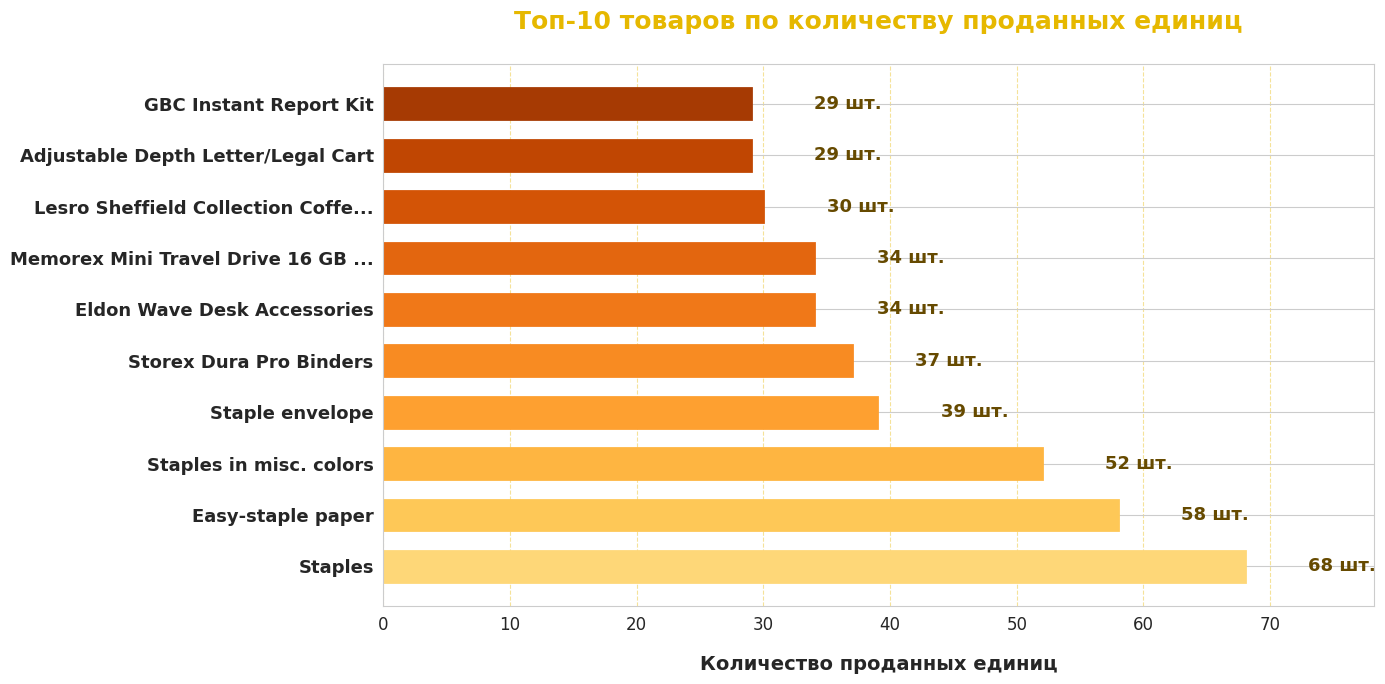

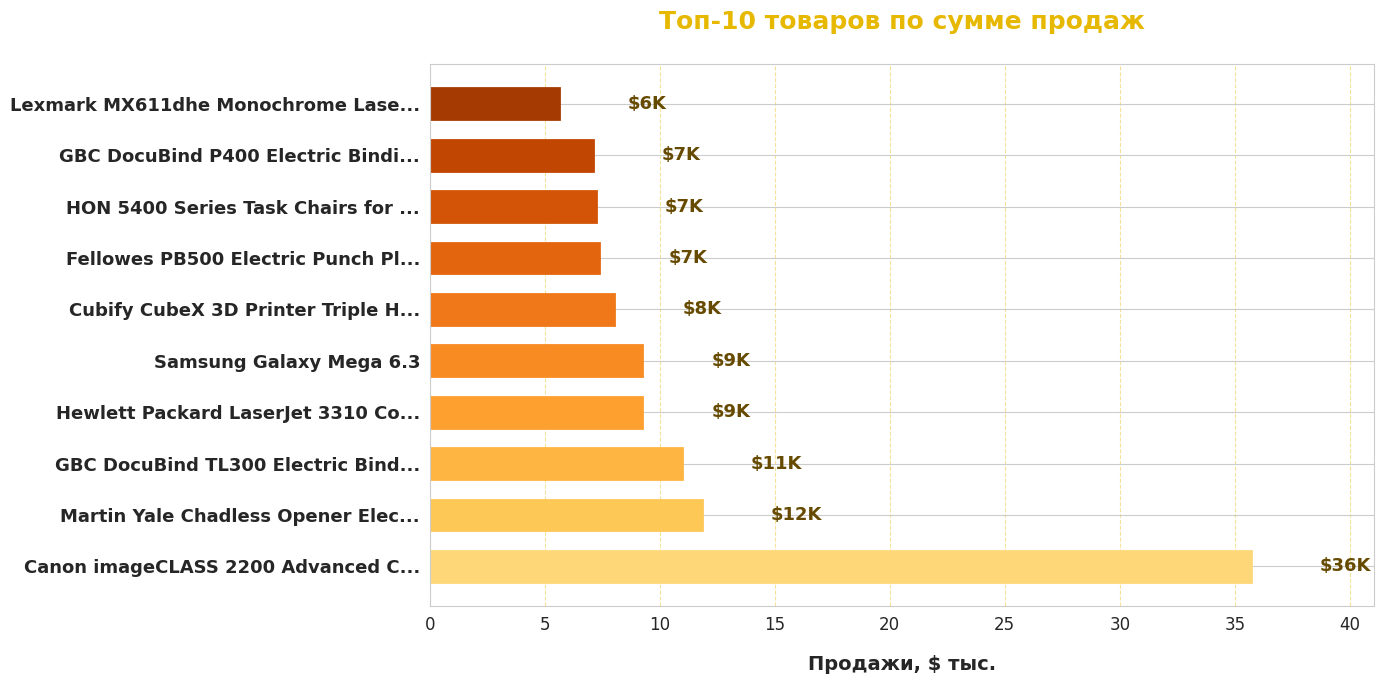

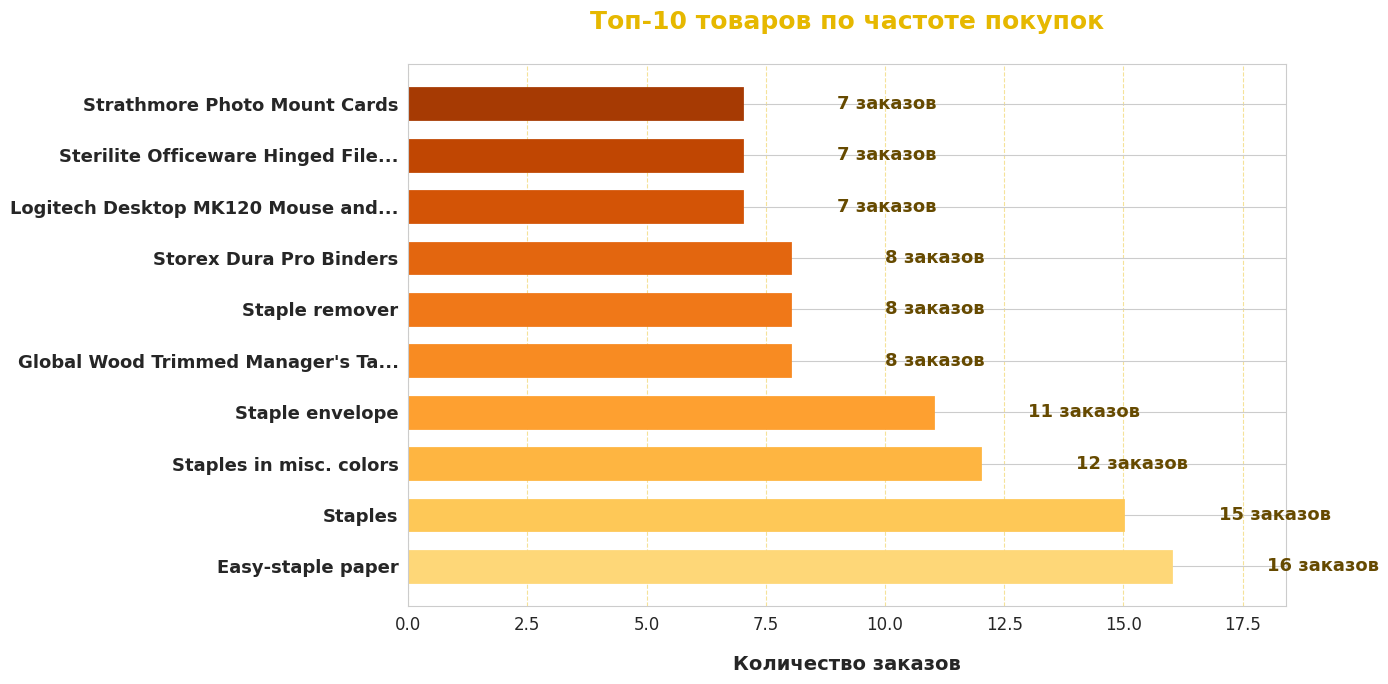


ТОП-5 САМЫХ ПОПУЛЯРНЫХ ТОВАРОВ

 По количеству проданных единиц:
1. Staples                                  |     68 шт.
2. Easy-staple paper                        |     58 шт.
3. Staples in misc. colors                  |     52 шт.
4. Staple envelope                          |     39 шт.
5. Storex Dura Pro Binders                  |     37 шт.

 По сумме продаж:
1. Canon imageCLASS 2200 Advanced Copier    | $    36K
2. Martin Yale Chadless Opener Electric Let | $    12K
3. GBC DocuBind TL300 Electric Binding Syst | $    11K
4. Hewlett Packard LaserJet 3310 Copier     | $     9K
5. Samsung Galaxy Mega 6.3                  | $     9K

 По частоте покупок (заказов):
1. Easy-staple paper                        |   16 заказов
2. Staples                                  |   15 заказов
3. Staples in misc. colors                  |   12 заказов
4. Staple envelope                          |   11 заказов
5. Global Wood Trimmed Manager's Task Chair |    8 заказов


In [22]:
# найти самые популярные товары (Product Name)

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['font.size'] = 12
yellow_palette = ['#FFF9E6', '#FFE680', '#FFD633', '#E6B800', '#997300']

# === 1. Топ-10 товаров по количеству проданных единиц (штук) ===
top_products_qty = df.groupby('productName')['quantity'].sum().nlargest(10).reset_index()

fig, ax = plt.subplots(figsize=(14, 7))
y_pos = np.arange(len(top_products_qty))

bars = ax.barh(
    y_pos,
    top_products_qty['quantity'],
    color=yellow_palette[2],
    edgecolor=yellow_palette[4],
    linewidth=2,
    height=0.6
)

# Градиент: чем больше продаж — тем темнее
for i, bar in enumerate(bars):
    shade = 0.3 + (i / len(bars)) * 0.6
    bar.set_color(plt.cm.YlOrBr(shade))

# Подписи справа
for i, (bar, qty) in enumerate(zip(bars, top_products_qty['quantity'])):
    width = bar.get_width()
    ax.text(width + 5, bar.get_y() + bar.get_height()/2,
            f'{qty:.0f} шт.',
            va='center', ha='left', fontsize=13, weight='bold', color='#664a00')

# Названия товаров (сокращаем длинные названия для читаемости)
product_names = []
for name in top_products_qty['productName']:
    if len(name) > 35:
        product_names.append(name[:32] + '...')
    else:
        product_names.append(name)

ax.set_yticks(y_pos)
ax.set_yticklabels(product_names, fontsize=13, weight='bold')

ax.set_xlabel('Количество проданных единиц', fontsize=14, weight='bold', labelpad=15)
ax.set_title('Топ-10 товаров по количеству проданных единиц',
             fontsize=18, weight='bold', color='#E6B800', pad=25)
ax.grid(axis='x', alpha=0.4, color='#E6B800', linestyle='--', linewidth=0.8)
ax.set_xlim(right=top_products_qty['quantity'].max() * 1.15)
plt.tight_layout()
plt.show()

# === 2. Топ-10 товаров по сумме продаж ===
top_products_sales = df.groupby('productName')['sales'].sum().nlargest(10).reset_index()

fig, ax = plt.subplots(figsize=(14, 7))
y_pos = np.arange(len(top_products_sales))

bars = ax.barh(
    y_pos,
    top_products_sales['sales'] / 1000,
    color=yellow_palette[3],
    edgecolor=yellow_palette[4],
    linewidth=2,
    height=0.6
)

for i, bar in enumerate(bars):
    shade = 0.3 + (i / len(bars)) * 0.6
    bar.set_color(plt.cm.YlOrBr(shade))

for i, (bar, sales) in enumerate(zip(bars, top_products_sales['sales'])):
    width = bar.get_width()
    ax.text(width + 3, bar.get_y() + bar.get_height()/2,
            f'${sales/1000:.0f}K',
            va='center', ha='left', fontsize=13, weight='bold', color='#664a00')

product_names = []
for name in top_products_sales['productName']:
    if len(name) > 35:
        product_names.append(name[:32] + '...')
    else:
        product_names.append(name)

ax.set_yticks(y_pos)
ax.set_yticklabels(product_names, fontsize=13, weight='bold')

ax.set_xlabel('Продажи, $ тыс.', fontsize=14, weight='bold', labelpad=15)
ax.set_title('Топ-10 товаров по сумме продаж',
             fontsize=18, weight='bold', color='#E6B800', pad=25)
ax.grid(axis='x', alpha=0.4, color='#E6B800', linestyle='--', linewidth=0.8)
ax.set_xlim(right=top_products_sales['sales'].max() / 1000 * 1.15)
plt.tight_layout()
plt.show()

# === 3. Топ-10 товаров по количеству заказов (сколько раз покупали) ===
top_products_orders = df.groupby('productName')['orderId'].nunique().nlargest(10).reset_index()
top_products_orders.columns = ['productName', 'orderCount']

fig, ax = plt.subplots(figsize=(14, 7))
y_pos = np.arange(len(top_products_orders))

bars = ax.barh(
    y_pos,
    top_products_orders['orderCount'],
    color=yellow_palette[1],
    edgecolor=yellow_palette[4],
    linewidth=2,
    height=0.6
)

for i, bar in enumerate(bars):
    shade = 0.3 + (i / len(bars)) * 0.6
    bar.set_color(plt.cm.YlOrBr(shade))

for i, (bar, orders) in enumerate(zip(bars, top_products_orders['orderCount'])):
    width = bar.get_width()
    ax.text(width + 2, bar.get_y() + bar.get_height()/2,
            f'{orders} заказов',
            va='center', ha='left', fontsize=13, weight='bold', color='#664a00')

product_names = []
for name in top_products_orders['productName']:
    if len(name) > 35:
        product_names.append(name[:32] + '...')
    else:
        product_names.append(name)

ax.set_yticks(y_pos)
ax.set_yticklabels(product_names, fontsize=13, weight='bold')

ax.set_xlabel('Количество заказов', fontsize=14, weight='bold', labelpad=15)
ax.set_title('Топ-10 товаров по частоте покупок',
             fontsize=18, weight='bold', color='#E6B800', pad=25)
ax.grid(axis='x', alpha=0.4, color='#E6B800', linestyle='--', linewidth=0.8)
ax.set_xlim(right=top_products_orders['orderCount'].max() * 1.15)
plt.tight_layout()
plt.show()

# === Итоговая таблица ===
print("\n" + "="*80)
print("ТОП-5 САМЫХ ПОПУЛЯРНЫХ ТОВАРОВ")
print("="*80)

print("\n По количеству проданных единиц:")
for i, (_, row) in enumerate(top_products_qty.head(5).iterrows(), 1):
    print(f"{i}. {row['productName'][:40]:40s} | {row['quantity']:>6.0f} шт.")

print("\n По сумме продаж:")
for i, (_, row) in enumerate(top_products_sales.head(5).iterrows(), 1):
    print(f"{i}. {row['productName'][:40]:40s} | ${row['sales']/1000:>6.0f}K")

print("\n По частоте покупок (заказов):")
for i, (_, row) in enumerate(top_products_orders.head(5).iterrows(), 1):
    print(f"{i}. {row['productName'][:40]:40s} | {row['orderCount']:>4d} заказов")

print("="*80)

Анализ товаров выявляет чёткое разделение на массовые низкобюджетные товары (Staples, Easy-staple paper) — они лидируют по количеству проданных единиц и частоте заказов, но вносят минимальный вклад в выручку.Высокомаржинальные технические устройства (Canon imageCLASS 2200, Martin Yale Chadless Opener) несмотря на малое количество продаж (1–3 единицы), генерируют значительную долю дохода (36 тыс. у.е. и 12 тыс. у.е.). Следовательно рутинные офисные принадлежности обеспечивают высокую частоту взаимодействия с клиентами,а крупные технические решения формируют основную прибыль.Товары Storex Dura Pro Binders или Staple envelope демонстрируют умеренный баланс между объёмом и ценой, подтверждая их роль как «работочих лошадок» ассортимента.

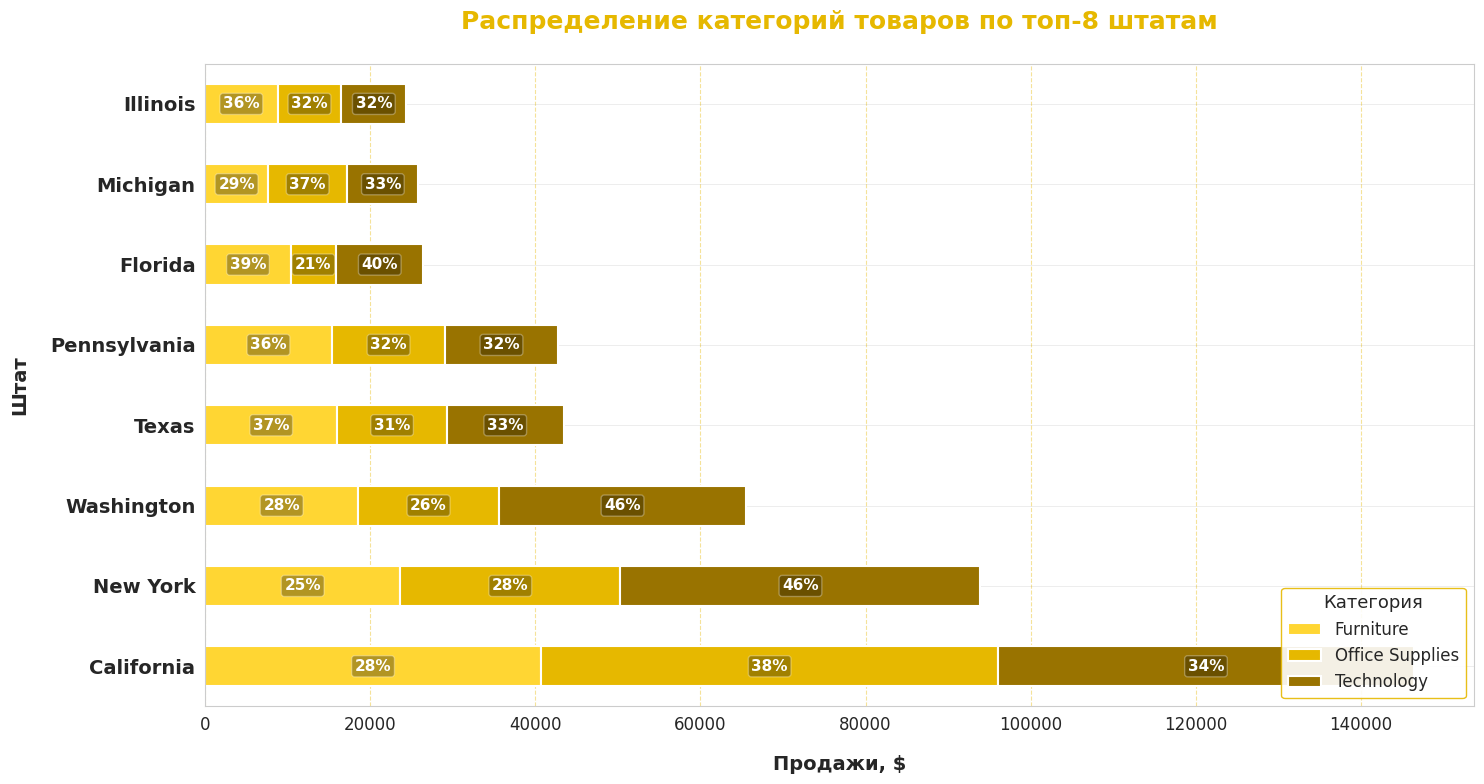

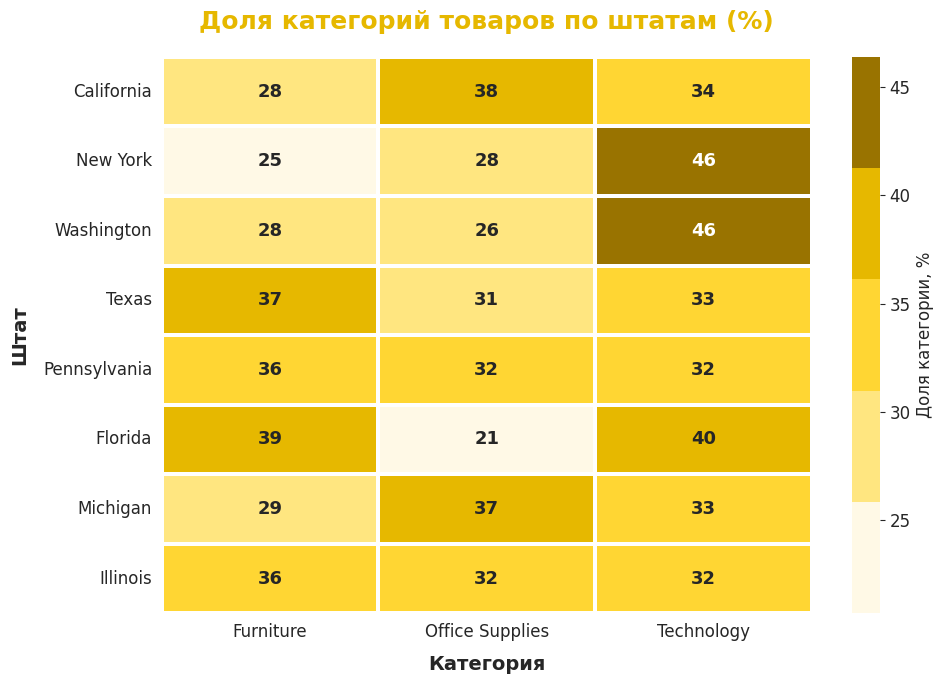


РАСПРЕДЕЛЕНИЕ КАТЕГОРИЙ ПО ТОП-8 ШТАТАМ
Штат            |   Technology |  Office Supplies |    Furniture |        Итого
------------------------------------------------------------------------------------------
California      | $        50K | $            55K | $        41K | $       146K
New York        | $        44K | $            27K | $        24K | $        94K
Washington      | $        30K | $            17K | $        19K | $        66K
Texas           | $        14K | $            13K | $        16K | $        43K
Pennsylvania    | $        14K | $            14K | $        15K | $        43K
Florida         | $        11K | $             5K | $        10K | $        26K
Michigan        | $         9K | $            10K | $         8K | $        26K
Illinois        | $         8K | $             8K | $         9K | $        24K

 Ключевые инсайты:
• Всего проанализировано штатов: 8
• Лидер по продажам техники: California
• Лидер по продажам канцелярии: California
• Самый «м

In [23]:
# изучить распределение категорий внутри городов (штатам)


sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 8)
plt.rcParams['font.size'] = 12
yellow_palette = ['#FFD633', '#E6B800', '#997300']  # 3 цвета для 3 категорий

# === 1. Подготовка данных: топ-8 штатов по продажам + распределение категорий ===
# Сначала найдём топ-8 штатов по общим продажам
top_states = df.groupby('state')['sales'].sum().nlargest(8).index.tolist()

# Фильтруем данные только по этим штатам
df_top_states = df[df['state'].isin(top_states)]

# Агрегация: продажи по штатам и категориям
state_category = df_top_states.groupby(['state', 'category'])['sales'].sum().unstack(fill_value=0)

# Сортируем штаты по общим продажам (убывание)
state_totals = state_category.sum(axis=1).sort_values(ascending=False)
state_category = state_category.loc[state_totals.index]

# Рассчитываем доли в процентах для подписей
state_category_pct = state_category.div(state_category.sum(axis=1), axis=0) * 100

# === 2. Стековая диаграмма распределения категорий ===
fig, ax = plt.subplots(figsize=(15, 8))

# Строим стековые столбцы
bars = state_category.plot(
    kind='barh',
    stacked=True,
    color=yellow_palette,
    edgecolor='white',
    linewidth=1.5,
    ax=ax
)

# Добавляем процентные подписи ВНУТРИ столбцов
for i, (state, row) in enumerate(state_category.iterrows()):
    cum_width = 0
    for j, (category, value) in enumerate(row.items()):
        pct = state_category_pct.loc[state, category]
        if pct >= 8:  # показываем подпись только если доля >= 8%
            # Центрируем подпись внутри сегмента
            x_pos = cum_width + value / 2
            ax.text(x_pos, i, f'{pct:.0f}%',
                    va='center', ha='center',
                    fontsize=11, weight='bold', color='white',
                    bbox=dict(boxstyle='round,pad=0.2', facecolor='black', alpha=0.3))
        cum_width += value

# Настройка осей
ax.set_xlabel('Продажи, $', fontsize=14, weight='bold', labelpad=15)
ax.set_ylabel('Штат', fontsize=14, weight='bold', labelpad=15)
ax.set_title('Распределение категорий товаров по топ-8 штатам',
             fontsize=18, weight='bold', color='#E6B800', pad=25)

# Названия штатов
ax.set_yticklabels(state_category.index, fontsize=14, weight='bold')

# Легенда
ax.legend(
    title='Категория',
    title_fontsize=13,
    fontsize=12,
    loc='lower right',
    frameon=True,
    facecolor='white',
    edgecolor='#E6B800',
    framealpha=0.9
)

# Сетка только по горизонтали для читаемости
ax.grid(axis='x', alpha=0.4, color='#E6B800', linestyle='--', linewidth=0.8)
ax.grid(axis='y', alpha=0.2, color='gray', linestyle='-', linewidth=0.5)

plt.tight_layout()
plt.show()

# === 3. Тепловая карта: штаты × категории (альтернативный взгляд) ===
# Нормализуем по штатам (доля каждой категории в штате)
heatmap_data = state_category_pct.round(1)

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='.0f',
    cmap=['#FFF9E6', '#FFE680', '#FFD633', '#E6B800', '#997300'],
    linewidths=1.5,
    linecolor='white',
    cbar_kws={'label': 'Доля категории, %', 'orientation': 'vertical'},
    ax=ax,
    annot_kws={'size': 13, 'weight': 'bold'}
)

ax.set_title('Доля категорий товаров по штатам (%)',
             fontsize=18, weight='bold', color='#E6B800', pad=20)
ax.set_xlabel('Категория', fontsize=14, weight='bold', labelpad=10)
ax.set_ylabel('Штат', fontsize=14, weight='bold', labelpad=10)
ax.tick_params(labelsize=12)

plt.tight_layout()
plt.show()

# === 4. Таблица с цифрами для отчёта ===
print("\n" + "="*90)
print("РАСПРЕДЕЛЕНИЕ КАТЕГОРИЙ ПО ТОП-8 ШТАТАМ")
print("="*90)
print(f"{'Штат':<15} | {'Technology':>12} | {'Office Supplies':>16} | {'Furniture':>12} | {'Итого':>12}")
print("-"*90)

for state in state_category.index:
    tech = state_category.loc[state, 'Technology'] if 'Technology' in state_category.columns else 0
    office = state_category.loc[state, 'Office Supplies'] if 'Office Supplies' in state_category.columns else 0
    furn = state_category.loc[state, 'Furniture'] if 'Furniture' in state_category.columns else 0
    total = tech + office + furn

    print(f"{state:<15} | ${tech/1000:>10.0f}K | ${office/1000:>14.0f}K | ${furn/1000:>10.0f}K | ${total/1000:>10.0f}K")

print("="*90)
print("\n Ключевые инсайты:")
print(f"• Всего проанализировано штатов: {len(top_states)}")
print(f"• Лидер по продажам техники: {state_category['Technology'].idxmax()}")
print(f"• Лидер по продажам канцелярии: {state_category['Office Supplies'].idxmax()}")
print(f"• Самый «мебельный» штат: {state_category['Furniture'].idxmax()}")
print("="*90)

Калифорния лидирует по продажам во всех трёх категориях, демонстрируя сбалансированный спрос. В Нью-Йорке и Вашингтоне доминирует Technology (по ~46% выручки), тогда как в Техасе и Флориде выше доля Furniture (33–40%), что отражает региональные особенности потребления.

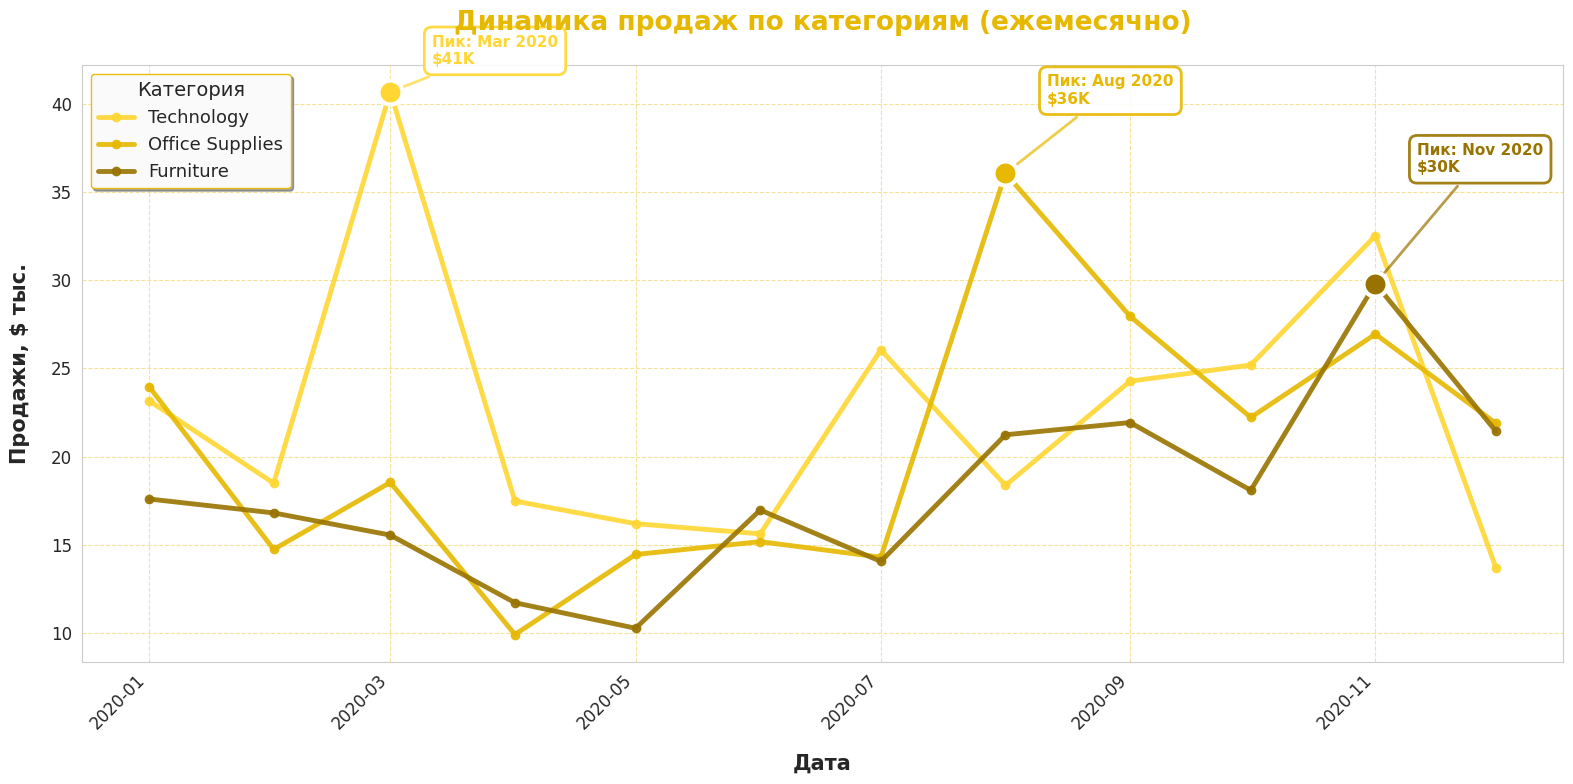

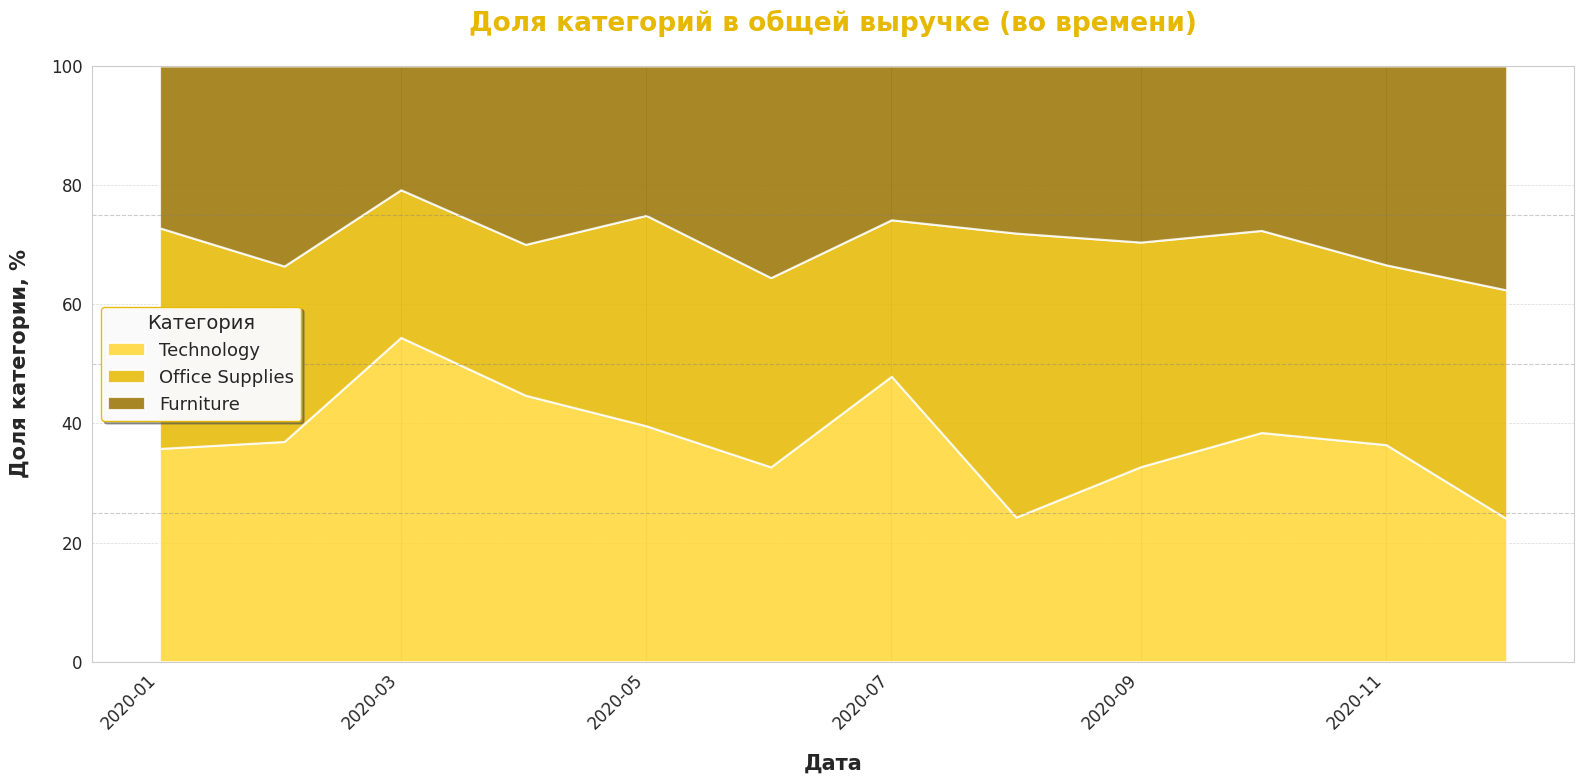


ДИНАМИКА ПРОДАЖ ПО КАТЕГОРИЯМ

Общая выручка за период: $733K

 Technology
   • Общие продажи: $     272K ( 37.1%)
   • Пик продаж: March 2020 ($    41K)
   • Среднемесячные продажи: $    23K

 Office Supplies
   • Общие продажи: $     246K ( 33.6%)
   • Пик продаж: August 2020 ($    36K)
   • Среднемесячные продажи: $    21K

 Furniture
   • Общие продажи: $     215K ( 29.4%)
   • Пик продаж: November 2020 ($    30K)
   • Среднемесячные продажи: $    18K

------------------------------------------------------------------------------------------
СЕЗОННОСТЬ ПО МЕСЯЦАМ (усреднено по годам):
------------------------------------------------------------------------------------------
Technology           | Лучший месяц: March        | Худший месяц: December    
Office Supplies      | Лучший месяц: August       | Худший месяц: April       
Furniture            | Лучший месяц: November     | Худший месяц: May         


In [24]:
# изучить динамику продаж внутри категорий

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (16, 8)
plt.rcParams['font.size'] = 12
yellow_palette = ['#FFD633', '#E6B800', '#997300']  # 3 цвета для 3 категорий

# === 1. Подготовка данных: группировка по месяцу и категории ===
# Создаём столбец месяца, если его нет
if 'yearMonth' not in df.columns:
    df['yearMonth'] = df['orderDate'].dt.to_period('M')

# Агрегация продаж по месяцу и категории
monthly_category = df.groupby(['yearMonth', 'category'])['sales'].sum().unstack(fill_value=0)
monthly_category.index = monthly_category.index.to_timestamp()  # для корректного отображения на графике

# Сортируем категории для согласованности
categories = ['Technology', 'Office Supplies', 'Furniture']
monthly_category = monthly_category[categories]

# === 2. Линейный график: динамика продаж по категориям ===
fig, ax = plt.subplots(figsize=(16, 8))

# Рисуем 3 линии (по одной на категорию)
for i, category in enumerate(categories):
    ax.plot(
        monthly_category.index,
        monthly_category[category] / 1000,  # в тысячах
        linewidth=3.5,
        marker='o',
        markersize=6,
        color=yellow_palette[i],
        label=category,
        alpha=0.9
    )

# Добавляем точки-акценты на пиковые месяцы для каждой категории
for i, category in enumerate(categories):
    peak_idx = monthly_category[category].idxmax()
    peak_val = monthly_category.loc[peak_idx, category] / 1000
    ax.scatter(
        peak_idx,
        peak_val,
        s=300,
        color=yellow_palette[i],
        edgecolor='white',
        linewidth=3,
        zorder=5,
        alpha=1
    )
    ax.annotate(
        f'Пик: {peak_idx.strftime("%b %Y")}\n${peak_val:.0f}K',
        xy=(peak_idx, peak_val),
        xytext=(30, 20 + i*30),
        textcoords='offset points',
        fontsize=11,
        weight='bold',
        color=yellow_palette[i],
        bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.9, edgecolor=yellow_palette[i], linewidth=2),
        arrowprops=dict(arrowstyle='->', color=yellow_palette[i], lw=2, alpha=0.7)
    )

# Оси и оформление
ax.set_xlabel('Дата', fontsize=15, weight='bold', labelpad=15)
ax.set_ylabel('Продажи, $ тыс.', fontsize=15, weight='bold', labelpad=15)
ax.set_title('Динамика продаж по категориям (ежемесячно)',
             fontsize=19, weight='bold', color='#E6B800', pad=25)
ax.legend(
    title='Категория',
    title_fontsize=14,
    fontsize=13,
    loc='upper left',
    frameon=True,
    facecolor='white',
    edgecolor='#E6B800',
    framealpha=0.95,
    shadow=True
)
ax.grid(alpha=0.4, color='#E6B800', linestyle='--', linewidth=0.8)
ax.set_axisbelow(True)

# Поворачиваем метки дат для читаемости
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

# === 3. Стековый график: доля категорий во времени ===
fig, ax = plt.subplots(figsize=(16, 8))

# Стековый график (заполняем 100%)
ax.stackplot(
    monthly_category.index,
    monthly_category['Technology'] / monthly_category.sum(axis=1) * 100,
    monthly_category['Office Supplies'] / monthly_category.sum(axis=1) * 100,
    monthly_category['Furniture'] / monthly_category.sum(axis=1) * 100,
    labels=categories,
    colors=yellow_palette,
    alpha=0.85,
    edgecolor='white',
    linewidth=1.5
)

# Горизонтальные линии-ориентиры для долей
for pct in [25, 50, 75]:
    ax.axhline(y=pct, color='gray', linestyle='--', linewidth=0.8, alpha=0.4)

# Оси и оформление
ax.set_xlabel('Дата', fontsize=15, weight='bold', labelpad=15)
ax.set_ylabel('Доля категории, %', fontsize=15, weight='bold', labelpad=15)
ax.set_title('Доля категорий в общей выручке (во времени)',
             fontsize=19, weight='bold', color='#E6B800', pad=25)
ax.legend(
    title='Категория',
    title_fontsize=14,
    fontsize=13,
    loc='center left',
    frameon=True,
    facecolor='white',
    edgecolor='#E6B800',
    framealpha=0.95,
    shadow=True
)
ax.grid(alpha=0.3, color='gray', linestyle='--', linewidth=0.5, axis='y')
ax.set_ylim(0, 100)
ax.set_axisbelow(True)

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# === 4. Таблица с ключевыми метриками ===
print("\n" + "="*90)
print("ДИНАМИКА ПРОДАЖ ПО КАТЕГОРИЯМ")
print("="*90)

# Общая статистика
total_sales = monthly_category.sum().sum()
print(f"\nОбщая выручка за период: ${total_sales/1000:,.0f}K\n")

for category in categories:
    sales = monthly_category[category].sum()
    pct = sales / total_sales * 100
    peak_month = monthly_category[category].idxmax()
    peak_val = monthly_category.loc[peak_month, category]
    avg_monthly = sales / len(monthly_category)

    print(f" {category}")
    print(f"   • Общие продажи: ${sales/1000:>8,.0f}K ({pct:>5.1f}%)")
    print(f"   • Пик продаж: {peak_month.strftime('%B %Y')} (${peak_val/1000:>6,.0f}K)")
    print(f"   • Среднемесячные продажи: ${avg_monthly/1000:>6,.0f}K")
    print()

# Сезонность: лучший и худший месяц года для каждой категории
print("-"*90)
print("СЕЗОННОСТЬ ПО МЕСЯЦАМ (усреднено по годам):")
print("-"*90)

df['month'] = df['orderDate'].dt.month
seasonality = df.groupby(['month', 'category'])['sales'].sum().unstack()
seasonality_pct = seasonality.div(seasonality.sum(axis=1), axis=0) * 100

for category in categories:
    best_month = seasonality[category].idxmax()
    worst_month = seasonality[category].idxmin()
    best_name = pd.to_datetime(f'2023-{best_month:02d}-01').strftime('%B')
    worst_name = pd.to_datetime(f'2023-{worst_month:02d}-01').strftime('%B')

    print(f"{category:20s} | Лучший месяц: {best_name:<12} | Худший месяц: {worst_name:<12}")

print("="*90)

В динамике продаж категория Technology лидирует по выручке (37.1%) и имеет пик в марте (41 тыс. у.е.),  доля в общей выручке растёт весной и снижается к декабрю. Это может быть связано с бюджетными циклами начала года. Office Supplies стабильна, но достигает максимума в августе (36 тыс. у.е.) — вероятно, из-за подготовки к новому учебному или финансовому году, а Furniture демонстрирует выраженную предновогоднюю сезонность с пиком в ноябре (30 тыс. у.е.), совпадающим с общим годовым максимумом продаж.

# Выводы

In [25]:
# на основании исследовательского анализа данных выявить закономерности и описать в формате нумерованного списка

 На основании исследовательского анализа данных выявленны ключевые закономерности:
 1. Высокая зависимость от ограниченной географии — топ-5 штатов (Калифорния, Нью-Йорк, Вашингтон, Техас, Пенсильвания) генерируют 62% выручки, при этом 47 штатов представлены в данных. Это создаёт определённый риск: любые региональные потрясения (экономические, логистические) могут существенно повлиять на доход. Рекомендация: разработать план экспансии в среднеактивные штаты (Мичиган, Иллинойс) с уже существующей клиентской базой для диверсификации.
 2. Техника — драйвер прибыли, канцелярия — драйвер лояльности — категория Technology обеспечивает 37% выручки при наименьшем числе заказов (средний чек 517 у.е.), тогда как Office Supplies формирует 56% всех заказов, но лишь 34% выручки (средний чек 194у.е.).  Необходимо сбалансировать удержание через массовые товары и монетизацию через оборудование.
 3. Чёткая сезонность по категориям требует адаптивного управления запасами — пики продаж не совпадают: Technology (март), Office Supplies (август), Furniture (ноябрь). Рекомендуется синхронизировать закупки и маркетинговые кампании с бюджетными циклами клиентов (начало финансового года, подготовка к учебному году, предновогодние закупки), избегая избыточных запасов в межсезонье.
 4. Региональная специализация спроса открывает возможности для таргетинга — в Нью-Йорке и Вашингтоне доля техники превышает 45% (корпоративный или госсектор), тогда как в Техасе и Флориде выше спрос на мебель (33–40%), вероятно, из-за роста удалённой работы. Использование географии для персонализации ассортимента и коммуникации — продвигать технику в деловых центрах, мебель — в регионах с развитым сегментом домашних офисов.
 5. Четверг–пятница — ключевые дни для корпоративных продаж — максимальная активность заказов приходится на конец рабочей недели, что типично для согласования закупок перед выходными. Возможность запускать промоакции и рассылки во вторник–среду даст попасть в окно принятия решений клиентов.
Данные инсайты позволяют перейти к стратегии снижения географических рисков, оптимизации ассортимента под сезонность и усилению монетизации высокомаржинальных категорий.